# Semantic Stories for Bot Detection on TwiBot-20

Every Twitter account of the TwiBot-20 benchmark is turned into a
natural-language *story* - a paragraph describing the profile, followed by one
sentence per post for the `k` most recent posts - and pre-trained encoders are
fine-tuned to read that story and answer one question: **bot or human?**

The method follows LEGOLAS (Pasquadibisceglie et al.), where the traces of an
event log are verbalized into stories and an encoder is fine-tuned on their
prefixes, so that performance can be measured as a function of how much of the
trace has been observed (*earliness*). Here the analogy is direct: the profile
fields play the role of the trace attributes, the sequence of posts plays the
role of the events, and the bot/human label is the outcome of the case.

The notebook is organised in two halves:

- **Sections 1-14** build everything once: the data (§3-5), the verbalization
  of the numeric fields (§6), the story template and its variants (§7), the
  audits that justify the template (§8-9), the datasets (§10) and the training,
  evaluation and reporting functions (§11-14). Every one of these sections is
  read-only with respect to `out/`.
- **Sections 15-20** are the experiments, one block each, with the model, the
  template and the seeds written out in the cell - nothing is selected through
  a configuration flag. Every experiment prints its own metrics and draws its
  own earliness figure, and every group ends with the comparison of the models
  it trained:
  - **Group A** (§15-16) - the full template on four encoders: which encoder?
  - **Group B** (§17-18) - the ablation of the template on `bert-medium`: what
    do the posts carry without the profile, and does a summary of the posts
    add anything to it?
  - **Group C** (§19-20) - the `verified` artifact: the same template with and
    without the one profile field that leaks the annotation.

Every run writes its metrics and predictions to `out/`. A block whose results
already exist loads them instead of training (`RETRAIN` in §1), so the whole
notebook re-runs in about ten minutes and regenerates every table and figure;
with `RETRAIN = True` it trains everything from scratch (~6 hours on a Quadro
RTX 5000). `PROJECT.md` documents the method and the design decisions,
`RESULTS.md` the numbers with their reading.


## 1. Setup

Standard library and numerical imports, and three settings that every later
cell reads:

- `DATA_DIR` - the directory with the official TwiBot-20 splits, three JSON
  files (`train.json`, `dev.json`, `test.json`) with 8,278 / 2,365 / 1,183
  accounts. The splits are used as they are, so the numbers stay comparable
  with published work.
- `SEEDS = (42, 1, 7)` - every experiment fine-tunes its model once per seed.
  The seed drives the initialization of the classification head and the order
  of the training batches, so the spread between the three runs of one
  configuration is the noise floor: a difference between two configurations
  smaller than that spread is not a result. Two seeds turned out to be too few
  to separate configurations that differ by less than 0.02 macro-F1, hence
  three.
- `RETRAIN = False` - a run whose results file `out/results_<model>_<variant>_seed<seed>.json`
  already exists is loaded rather than trained again. Set it to `True` to
  train everything from scratch.

The cell prints the library versions it is running on and the settings above.


In [1]:
import json
import os
import random
import re
import sys
import unicodedata
from collections import Counter, defaultdict
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# Directory holding the official splits: train.json, dev.json, test.json.
DATA_DIR = "data/"

# Every model is fine-tuned once per seed. The seed drives weight initialization
# and batch order, so the spread across seeds is what separates a real difference
# between models from plain run-to-run noise. Two seeds proved too few to
# separate configurations that differ by less than 0.02 macro-F1, hence three.
SEEDS = (42, 1, 7)

# A run whose out/results_*.json already exists is loaded, not trained again.
# Set to True to train everything from scratch (about six hours in all).
RETRAIN = False

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__}")
print(f"Splits read from '{DATA_DIR}' | seeds: {', '.join(str(seed) for seed in SEEDS)} | "
      f"retrain: {RETRAIN}")


Python 3.14.7 | numpy 2.5.2 | pandas 3.0.5
Splits read from 'data/' | seeds: 42, 1, 7 | retrain: False


## 2. GPU check

Fine-tuning a 125M-parameter encoder on ~49k stories of up to 512 tokens is
only practical on a GPU. The cell reports the `torch` and CUDA versions, the
device the notebook will actually use, its memory and its compute capability
(fp16 tensor cores exist from capability 7.0, which is what makes `fp16=True`
in §11 a speed-up rather than a slow-down). On the Quadro RTX 5000 used for
every run in `RESULTS.md`: 15.5 GiB, compute capability 7.5.


In [2]:
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"torch {torch.__version__} | CUDA {torch.version.cuda}")
    print(f"Training on {gpu.name}: {gpu.total_memory / 1024 ** 3:.1f} GiB, "
          f"compute capability {major}.{minor} (fp16 tensor cores from 7.0 on)")
else:
    print(f"torch {torch.__version__} | no GPU visible")
    print("Fine-tuning would fall back to CPU: hours per epoch instead of minutes.")


torch 2.14.0+cu126 | CUDA 12.6
Training on Quadro RTX 5000: 15.5 GiB, compute capability 7.5 (fp16 tensor cores from 7.0 on)


## 3. Loading and inspecting the training split

`train.json` is a list of 8,278 records, one per account. The cell loads it and
reports the shape of the raw data before anything is parsed, because every
later design decision rests on what is in there and what is not. A record has
six fields:

| Field | Content | Used |
|---|---|---|
| `ID` | the account id, as a padded string | yes |
| `profile` | 38 profile fields as returned by the Twitter API: counters (`followers_count`, `friends_count`, `statuses_count`, `favourites_count`, `listed_count`), flags (`verified`, `default_profile`, `geo_enabled`, `protected`, ...), `created_at`, `description`, `location`, `screen_name`, `name`, plus colours and image URLs | the counters, flags, dates and texts |
| `tweet` | the account's most recent posts, **as plain strings** - up to 200, no timestamp, no like or retweet count, no reply structure | yes |
| `domain` | one or more of `Politics`, `Business`, `Entertainment`, `Sports` | yes |
| `label` | `'0 '` human, `'1 '` bot, a padded string | yes |
| `neighbor` | follower / following lists, `null` for 754 accounts | no: the template describes an account, not the graph |

The `tweet` list is the *trace* in LEGOLAS terms - the ordered sequence of
events of one case - and its two limitations shape the experiments: it holds
text only, so no behavioural statistic that needs times or engagement can be
computed (§8 lists what that rules out), and it is capped at 200 posts, the
collection target of the dataset.

What the cell prints, and what each number means downstream:

- **Empty traces**: 55 accounts (0.7%) have no post at all. With a profile
  block they still get the `k = 0` story; without one (the `posts+stats`
  variant of §7) they have no story and drop out of the evaluation.
- **Labels**: 4,646 bots against 3,632 humans (56.1% bots). Close enough to
  balanced that accuracy and macro-F1 tell the same story; both are reported.
- **Posts per account**: median 200, mean 168.9. The survival table - how many
  accounts have at least 1, 3, 5, 10, 20 posts - is the earliness budget: 96.3%
  of the accounts survive to `k = 5`, so the prefix lengths used later score
  almost the same population at every `k`.


In [3]:
TRAIN_FILE = "train.json"

with open(os.path.join(DATA_DIR, TRAIN_FILE), "r", encoding="utf-8") as fh:
    train_raw = json.load(fh)

print(f"Loaded {len(train_raw)} user records from {os.path.join(DATA_DIR, TRAIN_FILE)}")
print("Fields of a record:", sorted(train_raw[0].keys()))

first_user = train_raw[0]
print(f"\nShape of the first record (user {first_user['ID'].strip()}):")
print(f"  profile: {len(first_user['profile'])} fields")
print(f"  tweet:   {len(first_user['tweet']) if first_user['tweet'] else 0} posts in the trace")
print(f"  domain:  {first_user['domain']}")
print(f"  label:   {first_user['label']!r} - a padded string, '1' = bot and '0' = human")

# Users with a missing trace or missing neighbour lists.
n_without_tweets = sum(1 for user in train_raw if not user.get("tweet"))
n_without_neighbors = sum(1 for user in train_raw if not user.get("neighbor"))
print(f"\nUsers with an empty trace: {n_without_tweets} "
      f"({100 * n_without_tweets / len(train_raw):.1f}%) - they only get the k=0 story")
print(f"Users with no neighbour lists: {n_without_neighbors} "
      f"({100 * n_without_neighbors / len(train_raw):.1f}%) - unused, the template ignores the graph")

# Labels are padded strings: "1" = bot, "0" = human.
label_counts = Counter(str(user["label"]).strip() for user in train_raw)
print(f"Labels: {label_counts['1']} bots / {label_counts['0']} humans "
      f"({100 * label_counts['1'] / len(train_raw):.1f}% bots - the split is close to balanced)")

# Trace length distribution.
trace_lengths = np.array([len(user["tweet"]) if user.get("tweet") else 0
                          for user in train_raw])
print(f"\nPosts per user - min {trace_lengths.min()} | "
      f"median {int(np.median(trace_lengths))} | mean {trace_lengths.mean():.1f} | "
      f"max {trace_lengths.max()} (the collection targets the 200 most recent posts)")

print("\nHow many users survive each prefix length, i.e. the earliness budget:")
for min_tweets in (1, 3, 5, 10, 20):
    covered = trace_lengths >= min_tweets
    print(f"  {min_tweets:2d}+ posts: {covered.sum():6d} users "
          f"({100 * covered.mean():.1f}%)")


Loaded 8278 user records from data/train.json
Fields of a record: ['ID', 'domain', 'label', 'neighbor', 'profile', 'tweet']

Shape of the first record (user 17461978):
  profile: 38 fields
  tweet:   200 posts in the trace
  domain:  ['Politics', 'Business', 'Entertainment']
  label:   '0' - a padded string, '1' = bot and '0' = human

Users with an empty trace: 55 (0.7%) - they only get the k=0 story
Users with no neighbour lists: 754 (9.1%) - unused, the template ignores the graph
Labels: 4646 bots / 3632 humans (56.1% bots - the split is close to balanced)

Posts per user - min 0 | median 200 | mean 168.9 | max 201 (the collection targets the 200 most recent posts)

How many users survive each prefix length, i.e. the earliness budget:
   1+ posts:   8223 users (99.3%)
   3+ posts:   8075 users (97.5%)
   5+ posts:   7969 users (96.3%)
  10+ posts:   7804 users (94.3%)
  20+ posts:   7581 users (91.6%)


## 4. Parsing: from raw records to typed users

Every value in TwiBot-20 is a string with a trailing space: `'False '`,
`'4646 '`, `'0 '`. That is harmless for text and dangerous for everything
else - `bool("False ")` is `True`, so a naive cast would mark every account as
verified and every account as protected. The four helpers at the top of the
cell exist for this: `clean_str` strips, `to_int` and `to_bool` strip and then
cast with an explicit fallback, `account_age_days` parses `created_at`
(`Mon Nov 10 20:53:38 +0000 2008`) and measures the age **against the
collection date of the dataset (2020)**, not against today - an account created
in 2008 is "eleven years old", whatever year the notebook is run in.

`parse_user` flattens one raw record into a typed dictionary of 24 fields
(the DataFrame below carries the 23 that are not the tweet list):

```
id, label, screen_name, name, description, location,
n_followers, n_following, n_statuses, n_favourites, n_listed,
verified, protected, default_profile, default_profile_image, geo_enabled, has_url,
account_age_days, domains (sorted, lower-case), n_domains,
n_neighbor_following, n_neighbor_followers, tweets (list of raw strings), n_tweets
```

The first three parsed rows are printed as a DataFrame so the columns can be
seen with real values - `@SHAQ`, human, 15.3M followers, 200 posts;
`@JenniferFishpaw`, bot, 0 followers, 38 days old, no post - followed by three
sanity checks that must all come out at zero: labels that failed to cast,
`created_at` values that failed to parse, missing screen names.

Two more prints matter for the template:

- **Domain combinations**: 15 distinct, the four single domains dominating
  (sports 2,015, entertainment 1,866, business 1,779, politics 1,465) and every
  subset of the four appearing at least 52 times. The profile block turns this
  into "is active in politics topics" or "is active in business, entertainment
  and politics".
- **The raw counters, before any verbalization**: followers have a mean of
  646k and a median of 1,940, with a maximum of 112M; statuses a mean of 21.6k
  and a median of 3.6k. Distributions this heavy-tailed are why §6 verbalizes
  counters into logarithmic bands rather than writing the digits.


In [4]:
# TwiBot-20 was collected in 2020: account age is measured against this
# reference date. The exact day is an assumption and is declared in the report.
REFERENCE_DATE = datetime(2020, 10, 1, tzinfo=timezone.utc)


def clean_str(value):
    """Return a stripped string, or None when the value is empty or a null marker."""
    if value is None:
        return None
    value = str(value).strip()
    return None if value in ("", "None", "null") else value


def to_int(value, default=0):
    """Cast a raw field to int, returning `default` when it cannot be parsed."""
    text = clean_str(value)
    if text is None:
        return default
    try:
        return int(float(text))
    except ValueError:
        return default


def to_bool(value):
    """Cast a raw flag to bool.

    Never use bool() directly here: fields are padded strings and
    bool("False ") evaluates to True.
    """
    text = clean_str(value)
    return text is not None and text.lower() == "true"


def account_age_days(created_at):
    """Days between account creation and REFERENCE_DATE, None when unparsable."""
    text = clean_str(created_at)
    if text is None:
        return None
    try:
        created = datetime.strptime(text, "%a %b %d %H:%M:%S %z %Y")
    except ValueError:
        return None
    return (REFERENCE_DATE - created).days


def parse_user(raw_user):
    """Flatten one raw TwiBot-20 record into a typed dictionary."""
    profile = raw_user.get("profile") or {}
    neighbor = raw_user.get("neighbor") or {}
    tweets = [text.strip() for text in (raw_user.get("tweet") or []) if clean_str(text)]

    # `domain` is a list and may hold several values; 253 users have all four.
    raw_domains = raw_user.get("domain") or []
    if isinstance(raw_domains, str):
        raw_domains = [raw_domains]
    domains = sorted({clean_str(d).lower() for d in raw_domains if clean_str(d)})

    return {
        "id":                    clean_str(raw_user.get("ID")),
        "label":                 to_int(raw_user.get("label"), default=-1),
        "domains":               domains,
        "n_domains":             len(domains),
        "screen_name":           clean_str(profile.get("screen_name")),
        "name":                  clean_str(profile.get("name")),
        "description":           clean_str(profile.get("description")),
        "location":              clean_str(profile.get("location")),
        "n_followers":           to_int(profile.get("followers_count")),
        "n_following":           to_int(profile.get("friends_count")),
        "n_statuses":            to_int(profile.get("statuses_count")),
        "n_favourites":          to_int(profile.get("favourites_count")),
        "n_listed":              to_int(profile.get("listed_count")),
        "verified":              to_bool(profile.get("verified")),
        "protected":             to_bool(profile.get("protected")),
        "geo_enabled":           to_bool(profile.get("geo_enabled")),
        "default_profile":       to_bool(profile.get("default_profile")),
        "default_profile_image": to_bool(profile.get("default_profile_image")),
        "has_url":               clean_str(profile.get("url")) is not None,
        "account_age_days":      account_age_days(profile.get("created_at")),
        "n_neighbor_following":  len(neighbor.get("following") or []),
        "n_neighbor_followers":  len(neighbor.get("follower") or []),
        "tweets":                tweets,
        "n_tweets":              len(tweets),
    }


train_users = [parse_user(user) for user in train_raw]

# Tabular view for the diagnostics below: the tweets are dropped and the domain
# list is flattened into a single string.
train_df = pd.DataFrame([
    {**{key: value for key, value in user.items() if key not in ("tweets", "domains")},
     "domains": ", ".join(user["domains"])}
    for user in train_users
])
print(f"Parsed {len(train_df)} users into {train_df.shape[1]} typed columns")
print(train_df.head(3))

# --- sanity checks: every one of these must come out clean, the template
# --- silently degrades on unparsed fields instead of raising.
print(f"\nLabels after casting: {train_df.label.value_counts().to_dict()} "
      f"(unparsable, cast to -1: {(train_df.label == -1).sum()})")
print(f"Unparsable created_at: {train_df.account_age_days.isna().sum()} | "
      f"missing screen_name: {train_df.screen_name.isna().sum()} - both expected to be 0")
print(f"\nDomain combinations ({train_df.domains.nunique()} distinct): "
      f"{train_df.domains.value_counts().to_dict()}")
print(f"\nverified: {train_df.verified.sum()} users "
      f"({100 * train_df.verified.mean():.1f}%) | "
      f"default profile layout: {train_df.default_profile.sum()} users "
      f"({100 * train_df.default_profile.mean():.1f}%)")
print("\nProfile counters as raw numbers, before any verbalization:")
print(train_df[["n_followers", "n_following", "n_statuses",
                "n_favourites", "account_age_days"]].describe())


Parsed 8278 users into 23 typed columns
                    id  label  n_domains      screen_name              name  \
0             17461978      0          3             SHAQ              SHAQ   
1  1297437077403885568      1          1  JenniferFishpaw  Jennifer Fishpaw   
2             17685258      0          3         parscale     Brad Parscale   

                                         description     location  \
0  VERY QUOTATIOUS, I PERFORM RANDOM ACTS OF SHAQ...  Orlando, FL   
1                                                NaN          NaN   
2  Owner @ Parscale Strategy. Senior Advisor Digi...      Florida   

   n_followers  n_following  n_statuses  ...  protected  geo_enabled  \
0     15349596          692        9798  ...      False         True   
1            0           44           0  ...      False        False   
2       762839          475        5518  ...      False         True   

   default_profile  default_profile_image  has_url  account_age_days  \
0    

## 5. Diagnostics: silent accounts and derived features

Three checks on the parsed training split, each feeding a decision in the
template.

**Silent accounts.** The 55 accounts with an empty trace are 40 humans and 15
bots, and their median `statuses_count` is 0: the trace is empty because the
account never posted, not because the collection failed. They are kept - the
profile block alone is a legitimate story for them.

**Derived features.** Two ratios carry more signal than the raw counters they
come from, and both are verbalized by the profile block (§6):

- `tweets_per_day` = `n_statuses / account_age_days` - the posting rate over
  the lifetime of the account;
- `followers_per_following` = `n_followers / n_following` - the follow ratio,
  the classic marker of an account that follows many and is followed by few.

**Humans against bots on medians and flags.** The printed tables are the
first look at what separates the two classes in the metadata, and they explain
most of what the classifier will learn:

| Feature (median) | Humans | Bots |
|---|---|---|
| followers | 26,809 | 713 |
| following | 612 | 824 |
| statuses | 6,580 | 2,006 |
| account age (days) | 3,410 | 2,450 |
| tweets per day | 2.44 | 1.05 |
| followers per following | 20.6 | 0.76 |

| Flag (share True) | Humans | Bots |
|---|---|---|
| `verified` | 0.566 | **0.000** |
| `default_profile` | 0.385 | 0.582 |
| `geo_enabled` | 0.522 | 0.335 |
| `has_url` | 0.606 | 0.393 |
| `protected` | 0.000 | 0.000 |

Two of these rows decide something. `protected` has zero variance and is left
out of the template. `verified` is true for more than half of the humans and
for **no bot at all**: the annotators of TwiBot-20 most likely used the blue
check as a heuristic when labelling humans, which makes the field an
annotation artifact rather than a property of bots. Every template of this
notebook leaves it out, except the one experiment (group C, §19) built to
measure how much it would be worth.


In [5]:
# Who are the users without a single tweet?
silent_users = train_df[train_df.n_tweets == 0]
silent_labels = silent_users.label.value_counts().to_dict()
print(f"Users with an empty trace: {len(silent_users)} "
      f"({silent_labels.get(0, 0)} humans, {silent_labels.get(1, 0)} bots)")
print(f"Their median statuses_count is {silent_users.n_statuses.median():.0f}: "
      f"the trace is empty because the account never posted, not because of a collection error")

# The trace is capped at 200 tweets: anything above it is a spurious record.
print(f"\nUsers whose trace exceeds the 200-post cap: {(train_df.n_tweets > 200).sum()}")

# Derived features: publication rate and followers / following ratio.
train_df["tweets_per_day"] = train_df.n_statuses / train_df.account_age_days.clip(lower=1)
train_df["followers_per_following"] = train_df.n_followers / train_df.n_following.clip(lower=1)

print("\nMedian per class of the features the template verbalizes (0 = human, 1 = bot):")
print(train_df.groupby("label")[["n_followers", "n_following", "n_statuses",
                                 "n_favourites", "account_age_days", "tweets_per_day",
                                 "followers_per_following", "n_tweets"]].median())

print("\nShare of True flags per class - 'verified' is the labelling artifact that\n"
      "every variant but 'full+verified' leaves out (section 7): no bot in this split carries it.")
print(train_df.groupby("label")[["verified", "default_profile", "default_profile_image",
                                 "geo_enabled", "has_url", "protected"]].mean().round(3))


Users with an empty trace: 55 (40 humans, 15 bots)
Their median statuses_count is 0: the trace is empty because the account never posted, not because of a collection error

Users whose trace exceeds the 200-post cap: 1

Median per class of the features the template verbalizes (0 = human, 1 = bot):
       n_followers  n_following  n_statuses  n_favourites  account_age_days  \
label                                                                         
0          26809.0        612.5      6580.0        1710.5            3409.5   
1            713.0        824.5      2006.0        1467.5            2450.5   

       tweets_per_day  followers_per_following  n_tweets  
label                                                     
0            2.440671                20.575668     200.0  
1            1.046851                 0.763462     199.0  

Share of True flags per class - 'verified' is the labelling artifact that
every variant but 'full+verified' leaves out (section 7): no bot in this 

## 6. Verbalizing the numeric fields

A counter is never written as digits. A tokenizer splits `1247893` into
sub-word pieces (`124`, `##78`, `##93`) that carry no ordinal meaning, so a
model reading digits cannot learn that a million followers is more than ten
thousand, and the heavy tails seen in §4 would make any linear scaling useless.
Each numeric field is instead mapped onto a **logarithmic band** and rendered
as an English phrase - the same treatment LEGOLAS gives to numerical
attributes, and the one TabLLM found to serialize tabular features best.

The four functions of this cell are the vocabulary of the profile block:

| Function | Input | Bands, in order |
|---|---|---|
| `verbalize_count(n, unit)` | any counter | no `unit` · fewer than a hundred · a few hundred · a few thousand · tens of thousands of · hundreds of thousands of · millions of |
| `verbalize_age(days)` | account age | less than three months · less than a year · one to three years · three to six years · six to ten years · more than ten years |
| `verbalize_posting_rate(per_day)` | statuses / age | posts very rarely · posts less than once a day · posts a few times a day · posts dozens of times a day · posts at an extremely high rate |
| `verbalize_follower_ratio(ratio)` | followers / following | follows far more accounts than follow it back · follows more accounts than follow it back · has about as many followers as it follows · has more followers than it follows · has many more followers than it follows · has vastly more followers than it follows |

So `@SHAQ`'s 15,349,596 followers become *millions of followers*, 692 followed
accounts become *follows a few hundred accounts*, and an account created in
2008 *was created more than ten years before the data was collected*.

The rest of the cell, `print_bands`, is a coverage check on the training set:
for every field it counts how many accounts fall in each band. A band that is
empty would be dead vocabulary; a band that absorbs most of the accounts would
be a feature that says nothing. Neither happens: followers spread over seven
bands, the largest holding 24.2% of the accounts (*a few hundred followers*),
account age over six, the largest 31.7%. The one thin band is *millions of
followed accounts*, six accounts, kept because it is true of them.


In [6]:
def verbalize_count(n, unit):
    """Verbalize a counter on a logarithmic scale."""
    if n == 0:            return f"no {unit}"
    if n < 100:           return f"fewer than a hundred {unit}"
    if n < 1_000:         return f"a few hundred {unit}"
    if n < 10_000:        return f"a few thousand {unit}"
    if n < 100_000:       return f"tens of thousands of {unit}"
    if n < 1_000_000:     return f"hundreds of thousands of {unit}"
    return f"millions of {unit}"


def verbalize_age(days):
    """Verbalize the account age at collection time."""
    if days is None:      return "an unknown time"
    if days < 90:         return "less than three months"
    if days < 365:        return "less than a year"
    if days < 3 * 365:    return "one to three years"
    if days < 6 * 365:    return "three to six years"
    if days < 10 * 365:   return "six to ten years"
    return "more than ten years"


def verbalize_posting_rate(posts_per_day):
    """Verbalize the average posting rate over the whole life of the account."""
    if posts_per_day < 0.1:   return "posts very rarely"
    if posts_per_day < 1:     return "posts less than once a day"
    if posts_per_day < 5:     return "posts a few times a day"
    if posts_per_day < 20:    return "posts dozens of times a day"
    return "posts at an extremely high rate"


def verbalize_follower_ratio(ratio):
    """Verbalize the followers / following ratio."""
    if ratio < 0.1:       return "follows far more accounts than follow it back"
    if ratio < 1:         return "follows more accounts than follow it back"
    if ratio < 10:        return "has a balanced follower ratio"
    if ratio < 100:       return "has many more followers than it follows"
    return "has vastly more followers than it follows"


# Bin coverage on the training set: a band holding almost every user carries no
# information, an empty band is a wasted branch of the template.
def print_bands(column, bands):
    print(f"{column} ({len(bands)} bands in use):")
    for band, count in bands.most_common():
        print(f"  {count:5d} users ({100 * count / len(train_df):4.1f}%)  {band}")
    print()


for column, unit in [("n_followers", "followers"), ("n_following", "followed accounts"),
                     ("n_statuses", "tweets"), ("n_favourites", "likes")]:
    print_bands(column, Counter(train_df[column].map(lambda value: verbalize_count(value, unit))))
print_bands("account_age_days", Counter(train_df.account_age_days.map(verbalize_age)))
print_bands("tweets_per_day", Counter(train_df.tweets_per_day.map(verbalize_posting_rate)))


n_followers (7 bands in use):
   2003 users (24.2%)  a few hundred followers
   1850 users (22.3%)  a few thousand followers
   1467 users (17.7%)  fewer than a hundred followers
   1316 users (15.9%)  tens of thousands of followers
    928 users (11.2%)  hundreds of thousands of followers
    637 users ( 7.7%)  millions of followers
     77 users ( 0.9%)  no followers

n_following (7 bands in use):
   3711 users (44.8%)  a few hundred followed accounts
   2884 users (34.8%)  a few thousand followed accounts
   1064 users (12.9%)  fewer than a hundred followed accounts
    463 users ( 5.6%)  tens of thousands of followed accounts
     79 users ( 1.0%)  hundreds of thousands of followed accounts
     71 users ( 0.9%)  no followed accounts
      6 users ( 0.1%)  millions of followed accounts

n_statuses (7 bands in use):
   2790 users (33.7%)  a few thousand tweets
   2376 users (28.7%)  tens of thousands of tweets
   1474 users (17.8%)  a few hundred tweets
   1217 users (14.7%)  fewer 

## 7. Building the stories

This is the template. A story is a single paragraph of English assembled from
up to three blocks, in this order:

1. **profile block** - the trace attributes: handle and name, domains, age,
   flags, the verbalized counters of §6, posting rate, follow ratio, bio,
   declared location;
2. **behaviour block** - what the observed posts look like *taken together*:
   how many of them are retweets, whether they repeat one another, how many
   distinct hashtags they use, what register they are written in. Four
   sentences at most;
3. **event block** - one sentence per post, for the `k` most recent posts.

### A worked example

One bot of the training split, `@caitlyn_lacy`, as the `full` template renders
it. At `k = 0` the story is the profile block alone:

> The account @caitlyn_lacy, named "☠️Caitlyn☠️", is active in entertainment
> topics. It was created six to ten years before the data was collected. It is
> uses the default profile layout, has geolocation enabled, links no website.
> It has a few hundred followers, follows a few hundred accounts, has posted
> tens of thousands of tweets in total and given tens of thousands of likes. It
> appears in fewer than a hundred public lists. It posts dozens of times a day
> and follows more accounts than follow it back. Its bio reads: "Nothing but
> hardcore vague postulating".

At `k = 1` one event block is appended - the most recent post:

> […] Most recent post: the account retweeted another account: "type of weather
> i crave [URL]". It carries 1 link.

At `k = 5` there are five, the last of which reads:

> […] Post 5 going back: the account posted: "Get that bag, bby 🖤🖤🖤 [URL]". It
> carries 1 link.

Every sentence of the profile block comes from one field: *is active in
entertainment topics* from `domain`, *six to ten years* from `created_at`,
*uses the default profile layout* / *has geolocation enabled* / *links no
website* from the three flags, the four counters from `verbalize_count`, *posts
dozens of times a day* and *follows more accounts than follow it back* from the
two derived ratios of §5, the bio truncated at `MAX_BIO_CHARS` = 200. An account
with a location gets *Declared location: London, England.* after the bio; one
without a bio gets *It has no bio.*

(The sentence *It is uses the default profile layout* is ungrammatical: it was
written to start with *verified* / *not verified*, and with that flag removed
the first item is a verb phrase. It is kept as is, because every run on disk
was trained on this exact text and changing it would make them
irreproducible.)

### The event block

`clean_tweet` turns one raw post into a body and a set of structural features.
Given the raw string

```
RT @someone: Here are of my favorite sketches from Inktober 2019. I'm mentally preparing for this year already! https://t.co/xyz
```

it strips the `RT @someone:` prefix and records `is_retweet = True` (the
information becomes structural, not textual - the retweeted handle is never
shown), replaces every URL with the placeholder `[URL]`, collapses whitespace,
truncates the body at `MAX_TWEET_CHARS` = 150 on a word boundary, and counts
hashtags, mentions and links. `event_block` then renders it:

```
Post 2 going back: the account retweeted another account: "Here are of my
favorite sketches from Inktober 2019. I'm mentally preparing for this year
already! [URL]". It carries 1 link.
```

The position phrase is *Most recent post* for the first and *Post `i` going
back* after that; the action is *posted*, *retweeted another account* or
*retweeted its own alternate account*; the trailing *It carries …* lists only
the non-zero counts, correctly pluralized, and is dropped when all three are
zero. Slang, profanity and emoji are kept on purpose: they are register
signal, and they are what the pre-trained encoders have seen most of.

### Prefixes and earliness

`build_stories` emits **one story per prefix length** for every account: with
a profile block, `k = 0` (profile only), `k = 1` (profile + most recent post),
… up to `k_max` or the number of posts the account has, whichever is smaller.
The prefixes are nested - the `k = 3` story is the `k = 2` story plus one
sentence - and their meaning does not depend on `k_max`: prefix 1 is always the
most recent post. Every prefix of an account is a separate training example
with the same label, which is how the encoder learns to classify from little
evidence as well as from much.

Earliness here is **positional, not temporal**: the dataset carries no
timestamp per post, so "`k = 3`" means "the three most recent posts have been
observed", not "a given amount of time has elapsed". The posts are assumed to
be in the order the Twitter API returns them, most recent first; the observed
ordering is consistent with that, but the dataset does not document it.

### The variants

`STORY_VARIANTS` names the four templates the experiments use. Each is a set
of three switches and a prefix cap; every function of this section takes the
variant as an argument, every experiment of §15-20 names one, and every artifact
a run writes carries its name, so no two experiments can overwrite each other's
files.

| Variant | Profile block | `verified` in the profile | Behaviour block | `k` |
|---|---|---|---|---|
| `full` | yes | no | no | 0..5 |
| `full+verified` | yes | yes | no | 0..5 |
| `full+stats` | yes | no | yes | 0..5 |
| `posts+stats` | no | - | yes | 1..8 |

On the same account, the four variants differ as follows (the cell prints all
four in full):

- `full+verified` inserts one clause in the third sentence of the profile:
  *It is **not verified,** uses the default profile layout, …* - the only
  difference from `full`.
- `full+stats` inserts the behaviour block between the profile and the first
  post: *[…] Its bio reads: "Nothing but hardcore vague postulating". **Of its 5
  most recent posts, 4 are retweets. They use no hashtag.** Most recent post:
  […]*
- `posts+stats` has no profile block at all; the story opens with the behaviour
  block and continues with up to eight posts: *Of its 8 most recent posts, 5
  are retweets. They use no hashtag. Most recent post: the account retweeted
  another account: "type of weather i crave [URL]". It carries 1 link. Post 2
  going back: […]*

Why each one exists:

- **`full`** is the LEGOLAS template transposed: attributes, then events.
- **`full+verified`** exists because of §5: `verified` is true for 56.6% of the
  humans and for none of the bots. Every other variant leaves it out, and the
  gap between `full` and `full+verified` (group C) measures how much of the
  performance that one field would buy.
- **`posts+stats`** answers a question `full` cannot: the earliness curve of the
  full template measures what the posts add *on top of* the profile, not what
  they carry *on their own*. Dropping the profile also frees the ~150-200
  tokens it occupies, which is what lets `k` grow from 5 to 8 inside the same
  512-token window: `k_max = 8` comes from the token audit of §9 (5.1% of the
  stories overflow at `k = 8`, against 4.4% for the full template at `k = 5`;
  at `k = 9` it jumps to 9.5%). An empty prefix would be an empty story, so this
  variant starts at `k = 1` and the accounts with no post produce no story (10
  of the 1,183 test accounts).
- **`full+stats`** asks whether summarizing the posts still helps when the
  profile is there too. Its `k = 0` story is identical to `full`'s, since the
  block needs at least one post; the block costs about 20 tokens, which takes
  the share of stories over 512 tokens at `k = 5` from 2.1% to 3.7% under
  WordPiece and from 4.1% to 5.2% under RoBERTa's BPE, so `k_max` stays at 5.

### The behaviour block

`post_stats_block` is the treatment of §6 - derive a value, render it as an
English phrase - applied to the observed posts instead of the profile fields.
Which statistics it may state was decided by the audit of §8: one sentence per
family of statistics that separates the classes and says something the other
sentences do not.

| Sentence | Fires when | Threshold |
|---|---|---|
| *Of its 8 most recent posts, 3 are retweets.* (*none is a retweet* / *one is a retweet* / *all are retweets*) | always | - |
| *Two of them are nearly identical.* | some pair of posts has a character-3-gram Jaccard similarity ≥ 0.9 | `NEAR_DUPLICATE` |
| *Its posts closely resemble one another.* | the mean pairwise similarity is ≥ 0.12, and the sentence above did not fire | `REPETITIVE` |
| *They use 4 different hashtags.* (*no hashtag* / *a single hashtag*) | always, counting distinct hashtags | - |
| *They are written mostly in a non-Latin script* | non-Latin share of the letters ≥ 0.5 | `NON_LATIN_SHARE` |
| *… rich in emoji* | at least one emoji per post | `EMOJI_PER_POST` |
| *… heavily capitalized* | upper-case share ≥ 0.10 of the text without the `[URL]` placeholders | `UPPERCASE_SHARE` |

At `k = 1` every sentence takes the singular (*Its most recent post is a
retweet. It uses no hashtag. It is rich in emoji.*). Three rules are
load-bearing:

- **it is computed on `observed_posts[:k]`, never on the whole trace** - a
  story at `k = 3` describes three posts. Summarizing all 200 would leak text
  the model has not been shown and would empty the earliness curve of its
  meaning;
- **it is placed before the posts** - at the top of the token budget truncation
  eats the tail of the story, so a summary put last would be the first thing
  lost;
- **it is measured on the cleaned, truncated bodies the story displays**, never
  on the raw posts. A block stating something the reader cannot see would be
  unverifiable from the story, and §8 shows what that rule threw out.

### What the cell prints

The number of training stories per variant and per `k` - 48,704 for the three
variants with a profile (8,278 at `k = 0`, then 8,223, 8,135, 8,075, 8,024,
7,969 as the accounts with fewer posts drop out), 64,118 for `posts+stats` -
then the same bot at full prefix length in each of the four variants, and one
human in `full`.


In [7]:
# --- template configuration ---
# The switches of a story. Every experiment names one variant; the functions
# below take it as an argument, so several variants can live in one notebook.
STORY_VARIANTS = {
    "full":          {"profile": True,  "post_stats": False, "verified": False, "k_max": 5},
    "full+verified": {"profile": True,  "post_stats": False, "verified": True,  "k_max": 5},
    "full+stats":    {"profile": True,  "post_stats": True,  "verified": False, "k_max": 5},
    "posts+stats":   {"profile": False, "post_stats": True,  "verified": False, "k_max": 8},
}

MAX_TWEET_CHARS = 150      # per-post truncation, applied before tokenization
MAX_BIO_CHARS = 200        # per-account bio truncation
# Thresholds of the behaviour block, all calibrated on the training split in
# section 8. Each one is the point where the sentence still fires often enough
# to be worth its tokens and still separates the classes.
NEAR_DUPLICATE = 0.9       # max 3-gram Jaccard above which two posts are "the same"
REPETITIVE = 0.12          # mean 3-gram Jaccard above which the posts "resemble one another"
UPPERCASE_SHARE = 0.10     # share of upper-case characters above which posts are "capitalized"
EMOJI_PER_POST = 1.0       # emoji per post above which the posts are "rich in emoji"
NON_LATIN_SHARE = 0.5      # share of non-Latin letters above which the script is "non-Latin"

URL_PATTERN = re.compile(r"https?://\S+")
MENTION_PATTERN = re.compile(r"@(\w+)")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
RETWEET_PATTERN = re.compile(r"^RT @(\w+)\s*:\s*", re.I)
LATIN_LETTER = re.compile(r"[A-Za-z]")


def clean_tweet(text, own_handle=None):
    """Return the cleaned body of a tweet and its structural features."""
    raw_text = text.strip()

    retweet_match = RETWEET_PATTERN.match(raw_text)
    if retweet_match:
        retweeted_handle = retweet_match.group(1)
        body = RETWEET_PATTERN.sub("", raw_text)
        is_self_retweet = (own_handle is not None
                           and retweeted_handle.lower() == own_handle.lower())
    else:
        retweeted_handle, body, is_self_retweet = None, raw_text, False

    features = {
        "n_urls":          len(URL_PATTERN.findall(body)),
        "n_mentions":      len(MENTION_PATTERN.findall(body)),
        "n_hashtags":      len(HASHTAG_PATTERN.findall(body)),
        "is_retweet":      retweeted_handle is not None,
        "is_self_retweet": is_self_retweet,
    }

    body = URL_PATTERN.sub("[URL]", body)
    body = re.sub(r"\s+", " ", body).strip()
    if len(body) > MAX_TWEET_CHARS:
        body = body[:MAX_TWEET_CHARS].rsplit(" ", 1)[0] + "..."
    return body, features


def profile_block(user, variant):
    """Verbalize the trace attributes: the fixed block heading every story."""
    sentences = []

    domains = user["domains"]
    if len(domains) >= 4:
        domain_text = "is active across politics, business, entertainment and sports"
    elif len(domains) > 1:
        domain_text = "is active in " + ", ".join(domains[:-1]) + f" and {domains[-1]}"
    else:
        domain_text = f"is active in {domains[0] if domains else 'no specific'} topics"

    name = user["name"] or "unnamed"
    sentences.append(f"The account @{user['screen_name']}, named \"{name}\", {domain_text}.")
    sentences.append("It was created "
                     f"{verbalize_age(user['account_age_days'])} before the data was collected.")

    flags = []
    if variant["verified"]:
        flags.append("verified" if user["verified"] else "not verified")
    flags.append("uses the default profile layout" if user["default_profile"]
                 else "has a customized profile layout")
    if user["default_profile_image"]:
        flags.append("still has the default profile picture")
    flags.append("has geolocation enabled" if user["geo_enabled"]
                 else "has geolocation disabled")
    flags.append("links a website in its bio" if user["has_url"] else "links no website")
    sentences.append("It is " + ", ".join(flags) + ".")

    posting_rate = verbalize_posting_rate(
        user["n_statuses"] / max(user["account_age_days"] or 1, 1))
    follower_ratio = verbalize_follower_ratio(
        user["n_followers"] / max(user["n_following"], 1))
    sentences.append(
        f"It has {verbalize_count(user['n_followers'], 'followers')}, "
        f"follows {verbalize_count(user['n_following'], 'accounts')}, "
        f"has posted {verbalize_count(user['n_statuses'], 'tweets')} in total "
        f"and given {verbalize_count(user['n_favourites'], 'likes')}. "
        f"It appears in {verbalize_count(user['n_listed'], 'public lists')}. "
        f"It {posting_rate} and {follower_ratio}."
    )

    if user["description"]:
        bio = re.sub(r"\s+", " ", URL_PATTERN.sub("[URL]", user["description"])).strip()
        sentences.append(f"Its bio reads: \"{bio[:MAX_BIO_CHARS]}\".")
    else:
        sentences.append("It has no bio.")

    if user["location"]:
        sentences.append(f"Declared location: {user['location']}.")

    return " ".join(sentences)


def plural(count, word):
    """Render `count` occurrences of `word`, pluralizing when needed."""
    return f"{count} {word}" + ("" if count == 1 else "s")


def event_block(position, body, features):
    """Verbalize a single post; `position` is 1 for the most recent one."""
    if features["is_self_retweet"]:
        action = "retweeted its own alternate account"
    elif features["is_retweet"]:
        action = "retweeted another account"
    else:
        action = "posted"

    position_text = "Most recent post" if position == 1 else f"Post {position} going back"
    meta_parts = [plural(features[key], word)
                  for key, word in [("n_hashtags", "hashtag"),
                                    ("n_mentions", "mention"),
                                    ("n_urls", "link")]
                  if features[key] > 0]
    meta_text = f" It carries {', '.join(meta_parts)}." if meta_parts else ""
    return f"{position_text}: the account {action}: \"{body}\".{meta_text}"


def char_trigrams(text):
    """Character 3-grams of a post: the unit of the near-duplicate comparison."""
    text = re.sub(r"\s+", " ", text.lower()).strip()
    return {text[i:i + 3] for i in range(max(len(text) - 2, 1))}


def pair_similarities(bodies):
    """Jaccard similarity of every pair of observed posts, as a list."""
    grams = [char_trigrams(body) for body in bodies]
    return [len(first & second) / len(first | second)
            for i, first in enumerate(grams) for second in grams[i + 1:]
            if first | second]


def post_stats_block(observed_posts):
    """Verbalize what the observed posts look like taken together.

    Four sentences at most, one per family of statistics that survived the audit
    of section 8: how much the account retweets, how much its posts repeat each
    other, how many distinct hashtags they carry, and what register they are
    written in. A family is one sentence and not three because its members
    correlate with one another; a statistic that correlates with a family
    already present says nothing new and costs tokens the posts need.

    Everything is measured on `bodies`, the cleaned and truncated text the story
    actually shows, never on the raw posts. A block that stated something the
    reader cannot see would be unverifiable from the story, and section 8 shows
    the trap concretely: mentions look discriminative on the raw text (d = 0.21)
    and are worth nothing on the visible text (d = 0.08), because their signal
    sits in the `RT @handle:` prefixes that `clean_tweet` strips.
    """
    bodies = [body for body, _ in observed_posts]
    features = [features for _, features in observed_posts]
    n_posts = len(bodies)
    single = n_posts == 1
    subject, verb = ("It", "is") if single else ("They", "are")

    # 1. Retweeting: the strongest single statistic of the audit (d = 0.39).
    n_retweets = sum(feature["is_retweet"] for feature in features)
    if single:
        sentences = [f"Its most recent post is "
                     f"{'a retweet' if n_retweets else 'not a retweet'}."]
    else:
        if n_retweets == 0:
            retweet_text = "none is a retweet"
        elif n_retweets == n_posts:
            retweet_text = "all are retweets"
        elif n_retweets == 1:
            retweet_text = "one is a retweet"
        else:
            retweet_text = f"{n_retweets} are retweets"
        sentences = [f"Of its {n_posts} most recent posts, {retweet_text}."]

    # 2. Repetition, graded: the near-duplicate pair is the sharp case, the mean
    #    similarity the diffuse one. Only the strongest of the two is said.
    if n_posts >= 2:
        similarities = pair_similarities(bodies)
        if similarities and max(similarities) >= NEAR_DUPLICATE:
            sentences.append("Two of them are nearly identical.")
        elif similarities and sum(similarities) / len(similarities) >= REPETITIVE:
            sentences.append("Its posts closely resemble one another.")

    # 3. Hashtags, counted distinct: the repetition ratio separates nothing
    #    (d = 0.04), the breadth does (d = 0.18).
    hashtags = {tag.lower() for body in bodies for tag in HASHTAG_PATTERN.findall(body)}
    if not hashtags:
        hashtag_text = "no hashtag"
    elif len(hashtags) == 1:
        hashtag_text = "a single hashtag"
    else:
        hashtag_text = f"{len(hashtags)} different hashtags"
    sentences.append(f"{subject} use{'s' if single else ''} {hashtag_text}.")

    # 4. Register. Measured without the [URL] placeholder: it is upper-case
    #    itself, and counting it made 45% of the "capitalized" firings spurious.
    text = " ".join(body.replace("[URL]", " ") for body in bodies)
    letters = [character for character in text if character.isalpha()]
    n_latin = sum(bool(LATIN_LETTER.match(character)) for character in letters)
    n_emoji = sum(unicodedata.category(character) == "So" or ord(character) >= 0x1F000
                  for character in text)

    register = []
    if letters and 1 - n_latin / len(letters) >= NON_LATIN_SHARE:
        register.append("written mostly in a non-Latin script")
    if n_emoji >= EMOJI_PER_POST * n_posts:
        register.append("rich in emoji")
    if text.strip() and sum(character.isupper()
                            for character in text) / len(text) >= UPPERCASE_SHARE:
        register.append("heavily capitalized")
    if register:
        listed = (register[0] if len(register) == 1
                  else ", ".join(register[:-1]) + " and " + register[-1])
        sentences.append(f"{subject} {verb} {listed}.")

    return " ".join(sentences)


def build_stories(user, variant):
    """Build one story per prefix length, as far as the trace allows.

    With the profile block the prefixes start at 0; without it they start at 1,
    since an empty prefix would be an empty story.
    """
    head = profile_block(user, variant) if variant["profile"] else None

    events, observed_posts = [], []
    for position, tweet in enumerate(user["tweets"][:variant["k_max"]], start=1):
        body, features = clean_tweet(tweet, own_handle=user["screen_name"])
        events.append(event_block(position, body, features))
        observed_posts.append((body, features))

    stories = []
    for k in range(0 if variant["profile"] else 1, len(events) + 1):
        parts = [head] if head else []
        if variant["post_stats"] and k:
            # On the prefix, never on the whole trace: the block must describe
            # what the model can see, or earliness stops meaning anything.
            parts.append(post_stats_block(observed_posts[:k]))
        parts.extend(events[:k])
        stories.append({"user_id": user["id"], "k": k,
                        "text": " ".join(parts), "label": user["label"]})
    return stories


# One list of training stories per variant. The dev and test splits follow in
# section 10, through the very same function.
train_stories = {name: [story for user in train_users for story in build_stories(user, variant)]
                 for name, variant in STORY_VARIANTS.items()}

without_posts = sum(1 for user in train_users if not user["tweets"])
print(f"Training stories per variant, from {len(train_users)} users:")
for name, stories in train_stories.items():
    stories_per_k = Counter(story["k"] for story in stories)
    print(f"  {name:14s} {len(stories):6d} stories | "
          + " | ".join(f"k={k}: {stories_per_k[k]}" for k in sorted(stories_per_k)))
print(f"{without_posts} users carry no post: they get the k=0 story of the variants with a "
      f"profile block,\nand no story at all in posts+stats, which has nothing left to "
      f"classify them on")

# Inspection: the same bot at full prefix length in every variant, and one human.
def example_story(name, label):
    return max((story for story in train_stories[name] if story["label"] == label),
               key=lambda story: (story["k"], story["user_id"]))

for name in STORY_VARIANTS:
    example = example_story(name, 1)
    print(f"\n{'=' * 70}\nEXAMPLE STORY - bot, variant '{name}', k={example['k']}, "
          f"{len(example['text'])} characters\n{'=' * 70}")
    print(example["text"])
example = example_story("full", 0)
print(f"\n{'=' * 70}\nEXAMPLE STORY - human, variant 'full', k={example['k']}, "
      f"{len(example['text'])} characters\n{'=' * 70}")
print(example["text"])


Training stories per variant, from 8278 users:
  full            48704 stories | k=0: 8278 | k=1: 8223 | k=2: 8135 | k=3: 8075 | k=4: 8024 | k=5: 7969
  full+verified   48704 stories | k=0: 8278 | k=1: 8223 | k=2: 8135 | k=3: 8075 | k=4: 8024 | k=5: 7969
  full+stats      48704 stories | k=0: 8278 | k=1: 8223 | k=2: 8135 | k=3: 8075 | k=4: 8024 | k=5: 7969
  posts+stats     64118 stories | k=1: 8223 | k=2: 8135 | k=3: 8075 | k=4: 8024 | k=5: 7969 | k=6: 7939 | k=7: 7893 | k=8: 7860
55 users carry no post: they get the k=0 story of the variants with a profile block,
and no story at all in posts+stats, which has nothing left to classify them on

EXAMPLE STORY - bot, variant 'full', k=5, 1314 characters
The account @caitlyn_lacy, named "☠️Caitlyn☠️", is active in entertainment topics. It was created six to ten years before the data was collected. It is uses the default profile layout, has geolocation enabled, links no website. It has a few hundred followers, follows a few hundred accounts

## 8. Audit of the template branches, per class

A sentence of the template earns its place only if it fires differently on
bots and on humans: one that fires the same way on both costs tokens - and the
budget is 512 - while returning nothing. This cell measures that, in three
parts, on a fixed window of the 8 most recent posts of every training account
(the window of `posts+stats`), whatever variant a later experiment uses.

**1. The retweet branches of the event block.** Over the 64,118 posts that end
up inside the stories, *retweeted another account* fires on 33.3% - 26.1% of
the humans' posts against 38.9% of the bots' - so it carries signal.
*Retweeted its own alternate account* fires on 0.75%, evenly across the
classes (0.68% against 0.81%): the branch stays in the code, since it is true
when it fires, but it separates nothing.

**2. The sentences of the behaviour block**, audited by **running the
template** on every account, so the audit can never drift from the code.
For each sentence the cell prints the share of humans and of bots it fires on,
and their ratio, `lift`: at 1.00 the sentence separates nothing, above 1.00 it
is a bot tell, below 1.00 a human tell. Reading the printed table:

| Sentence | Humans | Bots | Lift |
|---|---|---|---|
| *all are retweets* | 2.5% | 11.1% | 4.39 |
| *Two of them are nearly identical* | 5.9% | 9.5% | 1.60 |
| *heavily capitalized* | 12.9% | 17.4% | 1.35 |
| *rich in emoji* | 17.0% | 11.3% | 0.66 |
| *non-Latin script* | 4.6% | 1.0% | 0.21 |

Two of the sentences are human tells, and they are kept for that: a statistic
that separates the classes is useful in whichever direction it points.

**3. Why these statistics and not others.** The third part is the one that
decided what the block contains. It computes 21 candidate statistics on both
classes and reports **Cohen's *d*** on the pooled standard deviation - the gap
between the class means in units of the within-class spread, positive when the
statistic is higher among bots - and prints a verdict next to each. A candidate
has to clear two bars to ship:

1. **It has to separate the classes**, |*d*| ≥ 0.12. Below that the sentence
   is noise: link share (−0.05), type-token ratio (−0.03), mean post length
   (−0.03), reply share (+0.04), self-retweets (+0.02) all fail here.

   That threshold is a choice of this project, not a convention: Cohen's scale
   calls 0.2 *small*, so 0.12 is below even that. It is deliberately permissive
   because the question is not "is this effect notable" but "is this sentence
   worth five to twenty tokens of a 512-token budget" - and statistical
   significance cannot answer it, since with 3,592 humans and 4,631 bots
   |*d*| = 0.044 already gives p < 0.05 and would admit 12 of the 21 candidates.
   The value sits at a break in the printed ranking: nine candidates at 0.118
   and above, a gap of 0.021, then a tail that decays fast (0.097, 0.076,
   nothing else above 0.047). A bar at 0.08 would have been equally defensible,
   admitting one more statistic. The exact value matters little in the end: the
   three largest rejections below fail bar 2, the bar is overridden once on
   purpose, and group B measured the whole block at +0.0004 macro-F1 - any cut
   between 0.08 and 0.15 gives the same template.
2. **It has to say something new.** Statistics come in correlated families,
   and a family gets one sentence. Three candidates with a large *d* fail
   exactly here, and they are the instructive part of the audit:
   - *distinct retweet sources* (*d* = +0.35, the second-largest of all)
     correlates at *r* = 0.94 with the retweet count, and at a fixed number of
     retweets the gap between the classes is about zero. Bots do not retweet
     more accounts, they retweet more;
   - *posts ending in an ellipsis* (*d* = +0.26): 57.4% of the retweets end in
     one, 0.0% of the account's own posts do. It is the retweet count wearing a
     different hat;
   - *distinct accounts mentioned* (*d* = +0.21 on the raw posts) collapses to
     *d* = +0.08 on the text the story actually shows, because the signal sits
     in the `RT @handle:` prefixes that `clean_tweet` removes. Measuring on the
     raw posts would have shipped a sentence the reader cannot check - which is
     why the block is measured on the visible bodies.

What survives is one sentence per family: retweeting (*d* = +0.39), script
(−0.26), hashtag breadth (+0.18), capitalization (+0.17), repetition (+0.16
diffuse, +0.12 sharp), emoji (−0.13).

The cell closes with what **cannot** be measured on this dataset, and is
therefore not in the block: posting times and engagement (the posts are plain
strings), link destinations (3,856 of 3,904 URLs in a sample are `t.co`
shortlinks), the follow graph (`neighbor` is null).


In [8]:
# Fixed window: the audit describes the data, not one variant's stories.
AUDIT_K = 8

retweet_counts = defaultdict(Counter)
for user in train_users:
    for tweet in user["tweets"][:AUDIT_K]:
        _, features = clean_tweet(tweet, own_handle=user["screen_name"])
        counters = retweet_counts[user["label"]]
        counters["posts"] += 1
        counters["retweets"] += features["is_retweet"]
        counters["self_retweets"] += features["is_self_retweet"]

overall = sum(retweet_counts.values(), Counter())
print(f"How often each retweet branch of the template fires, over the "
      f"{overall['posts']} posts that end up inside the stories:\n")
print(f"  'retweeted another account':            {overall['retweets']:6d} posts "
      f"({100 * overall['retweets'] / overall['posts']:.1f}%)")
print(f"  'retweeted its own alternate account':  {overall['self_retweets']:6d} posts "
      f"({100 * overall['self_retweets'] / overall['posts']:.2f}%)")

print("\nPer class:")
for label, counters in sorted(retweet_counts.items()):
    n_posts = counters["posts"]
    print(f"  {'bots  ' if label else 'humans'} (label {label}): {n_posts:6d} posts | "
          f"retweets {100 * counters['retweets'] / n_posts:5.1f}% | "
          f"self-retweets {100 * counters['self_retweets'] / n_posts:.2f}%")

# --- the sentences of the behaviour block, audited by running the template ---


def observed_posts_of(user, k=AUDIT_K):
    return [clean_tweet(tweet, own_handle=user["screen_name"])
            for tweet in user["tweets"][:k]]


# Anchored on the left so that "none is a retweet" is not also counted as
# "one is a retweet", which is a substring of it.
BLOCK_SENTENCES = ("none is a retweet", "one is a retweet", "all are retweets",
                   "Two of them are nearly identical", "closely resemble one another",
                   "use no hashtag", "a single hashtag", "different hashtags",
                   "non-Latin script", "rich in emoji", "heavily capitalized")

block_counts = defaultdict(Counter)
for user in train_users:
    if not user["tweets"]:
        continue
    block = post_stats_block(observed_posts_of(user))
    block_counts[user["label"]]["accounts"] += 1
    for sentence in BLOCK_SENTENCES:
        if re.search(rf"(?<![A-Za-z]){re.escape(sentence)}", block):
            block_counts[user["label"]][sentence] += 1

print(f"\nHow often each sentence of the behaviour block fires, on the {AUDIT_K} most "
      f"recent posts\nof every account that has any:")
print(f"  {'sentence':34s} {'humans':>8s} {'bots':>8s} {'lift':>7s}")
for sentence in BLOCK_SENTENCES:
    share_human = block_counts[0][sentence] / block_counts[0]["accounts"]
    share_bot = block_counts[1][sentence] / block_counts[1]["accounts"]
    lift = share_bot / share_human if share_human else float("inf")
    print(f"  {sentence:34s} {100 * share_human:7.1f}% {100 * share_bot:7.1f}% {lift:7.2f}")
print("lift = bot share / human share; at 1.00 the sentence separates nothing")


# --- why these statistics and not others ------------------------------------
WORD_PATTERN = re.compile(r"[^\W\d_]+", re.U)


def candidate_statistics(user):
    """Every statistic that was considered for the behaviour block."""
    raw_posts = [tweet.strip() for tweet in user["tweets"][:AUDIT_K]]
    posts = observed_posts_of(user)
    bodies = [body for body, _ in posts]
    features = [feature for _, feature in posts]
    n_posts = len(bodies)

    plain = " ".join(body.replace("[URL]", " ") for body in bodies)
    letters = [c for c in plain if c.isalpha()]
    words = WORD_PATTERN.findall(plain.lower())
    similarities = pair_similarities(bodies)
    sources = [RETWEET_PATTERN.match(raw).group(1).lower()
               for raw in raw_posts if RETWEET_PATTERN.match(raw)]
    hashtags_visible = [h.lower() for b in bodies for h in HASHTAG_PATTERN.findall(b)]
    mentions_visible = [m.lower() for b in bodies for m in MENTION_PATTERN.findall(b)]
    mentions_raw = [m.lower() for b in raw_posts for m in MENTION_PATTERN.findall(b)]

    return {
        "retweet share":          sum(f["is_retweet"] for f in features) / n_posts,
        "mean pair similarity":   sum(similarities) / len(similarities) if similarities else 0.0,
        "max pair similarity":    max(similarities, default=0.0),
        "distinct hashtags":      len(set(hashtags_visible)),
        "uppercase share":        (sum(c.isupper() for c in plain) / len(plain)
                                   if plain.strip() else 0.0),
        "emoji per post":         sum(unicodedata.category(c) == "So" or ord(c) >= 0x1F000
                                      for c in plain) / n_posts,
        "non-Latin letter share": (1 - sum(bool(LATIN_LETTER.match(c)) for c in letters)
                                   / len(letters)) if letters else 0.0,

        "posts ending in an ellipsis": sum(b.endswith("\u2026") for b in bodies) / n_posts,
        "distinct retweet sources":    len(set(sources)),
        "distinct mentions, raw":      len(set(mentions_raw)),
        "distinct mentions, visible":  len(set(mentions_visible)),

        "link share":         sum(f["n_urls"] > 0 for f in features) / n_posts,
        "hashtags per post":  len(hashtags_visible) / n_posts,
        "hashtag repetition": len(hashtags_visible) / max(len(set(hashtags_visible)), 1),
        "reply share":        sum(raw.startswith("@") for raw in raw_posts) / n_posts,
        "self-retweet share": sum(f["is_self_retweet"] for f in features) / n_posts,
        "type-token ratio":   len(set(words)) / max(len(words), 1),
        "mean post length":   sum(len(b) for b in bodies) / n_posts,
        "post-length spread": float(np.std([len(b) for b in bodies])),
        "digit share":        (sum(c.isdigit() for c in plain) / len(plain)
                               if plain.strip() else 0.0),
        "exclamations per post": plain.count("!") / n_posts,
    }


VERDICTS = {
    "retweet share":          "kept: how much it retweets",
    "mean pair similarity":   "kept: repetition, diffuse case",
    "max pair similarity":    "kept: repetition, sharp case",
    "distinct hashtags":      "kept: hashtag breadth",
    "uppercase share":        "kept: register",
    "emoji per post":         "kept: register",
    "non-Latin letter share": "kept: register",
    "posts ending in an ellipsis": "dropped: r=0.77 with the retweet share",
    "distinct retweet sources":    "dropped: r=0.94 with the retweet count",
    "distinct mentions, raw":      "dropped: not visible in the story",
    "distinct mentions, visible":  "dropped: |d| below 0.12",
    "hashtags per post":           "dropped: r=0.89 with the distinct count",
}

candidates = {0: [], 1: []}
for user in train_users:
    if user["tweets"]:
        candidates[user["label"]].append(candidate_statistics(user))

print(f"\nEvery candidate statistic, measured on the same {AUDIT_K}-post window.")
print("d = (bot mean - human mean) / pooled sd; positive means higher among bots.")
print(f"  {'statistic':30s} {'humans':>9} {'bots':>9} {'d':>7}   verdict")
scored = []
for name in candidates[0][0]:
    human_values = np.array([row[name] for row in candidates[0]], dtype=float)
    bot_values = np.array([row[name] for row in candidates[1]], dtype=float)
    pooled = np.sqrt(((len(human_values) - 1) * human_values.var(ddof=1)
                      + (len(bot_values) - 1) * bot_values.var(ddof=1))
                     / (len(human_values) + len(bot_values) - 2))
    d = (bot_values.mean() - human_values.mean()) / pooled if pooled else 0.0
    scored.append((abs(d), name, human_values.mean(), bot_values.mean(), d))

for _, name, human_mean, bot_mean, d in sorted(scored, reverse=True):
    verdict = VERDICTS.get(name, "dropped: |d| below 0.12")
    print(f"  {name:30s} {human_mean:9.3f} {bot_mean:9.3f} {d:+7.3f}   {verdict}")

print("\nNot measurable on this dataset, and therefore not in the block:")
print("  posting times and engagement counts - 'tweet' is a list of plain strings,")
print("    with no timestamp and no like or retweet count attached to a post;")
print("  link destinations - 3856 of the 3904 URLs in a sample are t.co shortlinks,")
print("    so link diversity cannot be measured;")
print("  the follow graph - 'neighbor' is null in this dump.")


How often each retweet branch of the template fires, over the 64118 posts that end up inside the stories:

  'retweeted another account':             21344 posts (33.3%)
  'retweeted its own alternate account':     482 posts (0.75%)

Per class:
  humans (label 0):  28139 posts | retweets  26.1% | self-retweets 0.68%
  bots   (label 1):  35979 posts | retweets  38.9% | self-retweets 0.81%

How often each sentence of the behaviour block fires, on the 8 most recent posts
of every account that has any:
  sentence                             humans     bots    lift
  none is a retweet                     36.1%    29.1%    0.81
  one is a retweet                      17.1%    11.7%    0.69
  all are retweets                       2.5%    11.1%    4.39
  Two of them are nearly identical       5.9%     9.5%    1.60
  closely resemble one another           5.2%     6.5%    1.24
  use no hashtag                        47.9%    43.4%    0.91
  a single hashtag                      19.4%    17.5% 

## 9. Models, tokenizers and story-length audit

**The encoders.** Four are fine-tuned on the same stories, one entry each in
`MODEL_SPECS` - the tokenizer to load and a constructor for the model. This
dictionary is the only place that knows how a model differs from the others;
everything downstream is driven by it.

| Model | Parameters | Why it is in the comparison |
|---|---|---|
| `roberta-base` | 124.6M | the reference encoder |
| `prajjwal1/bert-medium` | 41.4M | how much is lost by shrinking the encoder to a third |
| `cardiffnlp/twitter-roberta-base-2021-124m` | 124.6M | the same architecture as the reference, further pre-trained on ~124M tweets: it isolates the effect of in-domain pre-training, since the stories quote the posts verbatim |
| `answerdotai/ModernBERT-base` | 149.6M | a recent encoder with an 8192-token window - unused here, the stories are budgeted for 512, so it competes without its structural advantage |

`prajjwal1/bert-medium` needs both halves of its entry spelled out: the
repository ships no serialized tokenizer (only a `vocab.txt`, so
`AutoTokenizer` fails and the identical `bert-base-uncased` vocabulary is used
instead), and its `config.json` declares no `model_type`, so the `Auto*`
classes cannot resolve the architecture and a `BertConfig` (8 layers, hidden
size 512, 8 heads) is built by hand.

The hyper-parameters are shared by all four (§11), so group A measures the
encoder. On the Quadro RTX 5000 at batch 32 × 512 tokens in fp16 the measured
peak memory is 7.9 GiB for `roberta-base`, 8.1 for `twitter-roberta` and 12.4
for `ModernBERT`, which is also ~1.8× slower than the others (no
FlashAttention on a Turing GPU).

**The token audit.** `MAX_LENGTH = 512` is the window of every encoder here,
and a story longer than that loses its tail - the oldest posts, exactly what
distinguishes prefix `k` from prefix `k − 1`. If many stories overflow at some
`k`, the earliness curve flattens there through truncation rather than through
genuine saturation, and if that happens for one tokenizer only, the comparison
between models is contaminated. The cell therefore takes a fixed random sample
of 2,000 stories per variant and, **for each tokenizer**, prints the median,
p95 and maximum length in tokens at every prefix length and the share of
stories over 512. BPE (RoBERTa, ModernBERT) and WordPiece (BERT) segment the
same text differently, so the numbers are per model.

Reading the printed tables for `full`: a median story at `k = 5` is 352
tokens under RoBERTa's BPE and 363 under WordPiece; the share over 512 is 4.4%,
2.4% and 3.3% for the RoBERTa, BERT and ModernBERT tokenizers. That is the
budget `k_max = 5` was chosen for, and the reference the posts-only variant is
held to at `k = 8` (5.1%). `full+verified` differs from `full` by one word and
is not repeated.


In [9]:
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          BertConfig, BertForSequenceClassification)


MODEL_SPECS = {
    "roberta-base": {
        "tokenizer": "roberta-base",
        "build_model": lambda: AutoModelForSequenceClassification.from_pretrained(
            "roberta-base", num_labels=2),
    },
    "prajjwal1/bert-medium": {
        "tokenizer": "bert-base-uncased",   # the repo ships no tokenizer of its own
        "build_model": lambda: BertForSequenceClassification.from_pretrained(
            "prajjwal1/bert-medium",        # no `model_type`: the config is explicit
            config=BertConfig(hidden_size=512, num_hidden_layers=8,
                              num_attention_heads=8, intermediate_size=2048,
                              num_labels=2)),
    },
    "cardiffnlp/twitter-roberta-base-2021-124m": {
        "tokenizer": "cardiffnlp/twitter-roberta-base-2021-124m",
        "build_model": lambda: AutoModelForSequenceClassification.from_pretrained(
            "cardiffnlp/twitter-roberta-base-2021-124m", num_labels=2),
    },
    "answerdotai/ModernBERT-base": {
        "tokenizer": "answerdotai/ModernBERT-base",
        "build_model": lambda: AutoModelForSequenceClassification.from_pretrained(
            "answerdotai/ModernBERT-base", num_labels=2),
    },
}


def model_slug(model_name):
    """Filesystem-safe form of a hub name, which carries a '/'."""
    return model_name.replace("/", "-")


MAX_LENGTH = 512   # the window of every encoder here; longer stories lose their oldest posts

# The audit is descriptive, so any fixed seed does: the first one keeps it reproducible.
print(f"Story length in tokens on 2000 sampled stories per variant. The column that "
      f"matters is the last one:\nthose stories exceed the {MAX_LENGTH}-token window and "
      f"lose their oldest posts to truncation.\n")

for variant_name in ("full", "full+stats", "posts+stats"):
    sampled_stories = random.Random(SEEDS[0]).sample(train_stories[variant_name], 2000)
    print(f"{'#' * 70}\nVARIANT '{variant_name}'\n{'#' * 70}")
    for model_name, spec in MODEL_SPECS.items():
        tokenizer = AutoTokenizer.from_pretrained(spec["tokenizer"])
        print(f"{model_name} - tokenizer {spec['tokenizer']}, vocabulary {tokenizer.vocab_size}")
        print(f"  {'posts':>5} {'stories':>8} {'median':>7} {'p95':>6} {'max':>6} "
              f"{'truncated':>10}")
        for k in sorted({story["k"] for story in sampled_stories}):
            token_lengths = np.array([len(tokenizer(story["text"])["input_ids"])
                                      for story in sampled_stories if story["k"] == k])
            print(f"  k={k:<4d} {len(token_lengths):8d} "
                  f"{int(np.median(token_lengths)):7d} "
                  f"{int(np.percentile(token_lengths, 95)):6d} "
                  f"{token_lengths.max():6d} "
                  f"{100 * (token_lengths > MAX_LENGTH).mean():9.1f}%")
        print()


Story length in tokens on 2000 sampled stories per variant. The column that matters is the last one:
those stories exceed the 512-token window and lose their oldest posts to truncation.

######################################################################
VARIANT 'full'
######################################################################


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (921 > 512). Running this sequence through the model will result in indexing errors


roberta-base - tokenizer roberta-base, vocabulary 50265
  posts  stories  median    p95    max  truncated
  k=0         342     145    185    310       0.0%
  k=1         337     185    253    460       0.0%
  k=2         316     229    322    921       1.3%
  k=3         331     272    428    979       3.6%
  k=4         336     313    428   1110       2.7%
  k=5         338     352    499   1299       4.4%

prajjwal1/bert-medium - tokenizer bert-base-uncased, vocabulary 30522
  posts  stories  median    p95    max  truncated
  k=0         342     145    176    260       0.0%


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


  k=1         337     187    230    329       0.0%
  k=2         316     231    294    523       0.3%
  k=3         331     276    353    552       0.3%
  k=4         336     321    407    747       0.9%
  k=5         338     363    458    660       2.4%



...

roberta-base - tokenizer roberta-base, vocabulary 50265
  posts  stories  median    p95    max  truncated
  k=1         255      57     96    198       0.0%
  k=2         238     102    170    449       0.0%
  k=3         253     146    248    598       0.8%
  k=4         273     192    294    834       1.8%
  k=5         269     228    367    820       3.0%
  k=6         234     271    451   1322       4.3%
  k=7         241     312    523    889       5.4%
  k=8         237     360    532   1010       6.3%



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (576 > 512). Running this sequence through the model will result in indexing errors


prajjwal1/bert-medium - tokenizer bert-base-uncased, vocabulary 30522
  posts  stories  median    p95    max  truncated
  k=1         255      63     95    157       0.0%
  k=2         238     110    154    280       0.0%
  k=3         253     155    234    295       0.0%
  k=4         273     205    289    576       0.4%
  k=5         269     239    350    592       0.7%
  k=6         234     289    402    596       0.9%
  k=7         241     325    466    753       3.3%
  k=8         237     382    518    782       6.3%



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (598 > 512). Running this sequence through the model will result in indexing errors


cardiffnlp/twitter-roberta-base-2021-124m - tokenizer cardiffnlp/twitter-roberta-base-2021-124m, vocabulary 50265
  posts  stories  median    p95    max  truncated
  k=1         255      57     96    198       0.0%
  k=2         238     102    170    449       0.0%
  k=3         253     146    248    598       0.8%
  k=4         273     192    294    834       1.8%
  k=5         269     228    367    820       3.0%
  k=6         234     271    451   1322       4.3%
  k=7         241     312    523    889       5.4%
  k=8         237     360    532   1010       6.3%

answerdotai/ModernBERT-base - tokenizer answerdotai/ModernBERT-base, vocabulary 50280
  posts  stories  median    p95    max  truncated
  k=1         255      60     99    164       0.0%
  k=2         238     107    164    349       0.0%
  k=3         253     151    245    445       0.0%
  k=4         273     196    285    673       0.7%
  k=5         269     231    349    627       1.9%
  k=6         234     278    437    

## 10. Dev and test splits, datasets

The dev and test splits go through exactly the same pipeline as the training
split - `parse_user`, then `build_stories` with each variant - and the
official splits are used as they are, so the results stay comparable with
published work. `load_split` parses one file; the cell then builds
`datasets[variant][split]`, a HuggingFace `Dataset` of plain-text stories for
each of the four variants and each of the three splits, and prints the table
of sizes:

| | train | dev | test |
|---|---|---|---|
| accounts | 8,278 | 2,365 | 1,183 |
| `full`, `full+verified`, `full+stats` | 48,704 | 13,911 | 6,902 |
| `posts+stats` | 64,118 | 18,317 | 9,066 |

Each dataset carries four columns: `text` (the story), `labels` (0 human, 1
bot), and `k` and `user_id`, which the model never sees - they are carried
along because the evaluation of §12 groups the predictions by prefix length
and by account.

Tokenization depends on the model, so it is not done here: `tokenize_splits`
takes a variant and a tokenizer and is called inside each experiment (§14). It
tokenizes with `truncation=True, max_length=512`, which cuts the *end* of a
story that is too long - the oldest posts, as §9 measured - and drops the
`text` column. Padding is left to the collator at training time, so every batch
is padded to its own longest story rather than to 512.


In [10]:
import gc

from datasets import Dataset


def load_split(filename):
    """Parse one split file into typed users."""
    with open(os.path.join(DATA_DIR, filename), "r", encoding="utf-8") as fh:
        raw_users = json.load(fh)
    users = [parse_user(user) for user in raw_users]
    users = [user for user in users if user["label"] in (0, 1)]
    del raw_users
    gc.collect()
    return users


dev_users = load_split("dev.json")
test_users = load_split("test.json")
split_users = {"train": train_users, "dev": dev_users, "test": test_users}


def to_hf_dataset(stories):
    """Turn a list of stories into a HuggingFace Dataset."""
    return Dataset.from_dict({
        "text":    [story["text"] for story in stories],
        "labels":  [story["label"] for story in stories],
        "k":       [story["k"] for story in stories],
        "user_id": [story["user_id"] for story in stories],
    })


# datasets[variant][split]: the plain-text stories of every variant and split.
datasets = {}
for name, variant in STORY_VARIANTS.items():
    datasets[name] = {
        "train": to_hf_dataset(train_stories[name]),
        "dev":   to_hf_dataset([s for user in dev_users for s in build_stories(user, variant)]),
        "test":  to_hf_dataset([s for user in test_users for s in build_stories(user, variant)]),
    }

print("Official splits, used as they are so the results stay comparable:")
print(f"  {'':14s} " + " ".join(f"{split:>16s}" for split in split_users))
print(f"  {'users':14s} " + " ".join(f"{len(users):16d}" for users in split_users.values()))
for name in STORY_VARIANTS:
    print(f"  {name:14s} " + " ".join(f"{len(datasets[name][split]):9d} stories"
                                     for split in split_users))


def tokenize_splits(variant_name, tokenizer):
    """Tokenize the three splits of one variant with the tokenizer of one model."""
    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

    return {split: dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
            for split, dataset in datasets[variant_name].items()}


print("\nColumns carried by every split before tokenization "
      "('k' and 'user_id' are for the evaluation, the model never sees them):")
print(datasets["full"]["train"])


Official splits, used as they are so the results stay comparable:
                            train              dev             test
  users                      8278             2365             1183
  full               48704 stories     13911 stories      6902 stories
  full+verified      48704 stories     13911 stories      6902 stories
  full+stats         48704 stories     13911 stories      6902 stories
  posts+stats        64118 stories     18317 stories      9066 stories

Columns carried by every split before tokenization ('k' and 'user_id' are for the evaluation, the model never sees them):
Dataset({
    features: ['text', 'labels', 'k', 'user_id'],
    num_rows: 48704
})


## 11. Fine-tuning

`fine_tune` builds the model of one entry of `MODEL_SPECS` and trains it on the
tokenized stories of one variant with the HuggingFace `Trainer`. Every
experiment of §15-20 goes through this function with the same
hyper-parameters, so any difference in the results comes from the encoder or
the template and not from the schedule; between two runs of the same
configuration only the seed changes.

| Setting | Value |
|---|---|
| task | sequence classification, two labels |
| epochs | 3 |
| batch | 32 stories, each up to 512 tokens |
| learning rate | 3e-5, linear decay, warm-up over the first 10% of the steps |
| weight decay | 0.01 |
| precision | fp16 |
| evaluation | on the dev split at the end of every epoch |
| checkpoint selection | the epoch with the best **dev macro-F1** is the model that goes on to the test set (`load_best_model_at_end`) |
| checkpoints kept | 2 - the best and the last, ~1.5 GB each, under `out/<model>_<variant>_seed<seed>/` |

`compute_metrics` reports accuracy, macro-F1 and weighted-F1 - the metrics of
LEGOLAS - every time the trainer evaluates. The function prints the model size,
the number of training stories, the device and the settings before training
starts, then the trainer's own progress and per-epoch dev metrics.

Two notes on `transformers` 5.x: `warmup_ratio` no longer exists and
`warmup_steps` accepts a float, read as a fraction of the total steps;
`evaluation_strategy` has become `eval_strategy`.


In [11]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
from transformers import DataCollatorWithPadding, Trainer, TrainingArguments, set_seed


def compute_metrics(eval_prediction):
    """Accuracy, macro-F1 and weighted-F1 on a batch of predictions."""
    predictions = eval_prediction.predictions.argmax(-1)
    labels = eval_prediction.label_ids
    return {
        "accuracy":    accuracy_score(labels, predictions),
        "macro_f1":    f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted"),
    }


def fine_tune(model_name, variant_name, tokenized_datasets, tokenizer, seed):
    """Fine-tune one model on the training stories of one variant, selecting on dev macro-F1."""
    set_seed(seed)
    model = MODEL_SPECS[model_name]["build_model"]()

    training_args = TrainingArguments(
        output_dir=os.path.join("out", f"{model_slug(model_name)}_{variant_name}_seed{seed}"),
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=3e-5,      # RoBERTa is lr-sensitive; 2e-5 is the alternative tried
        warmup_steps=0.1,        # transformers 5.x: a float means a fraction of total steps
        weight_decay=0.01,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,      # only the best and the last checkpoint (~1.5 GB each)
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        logging_steps=100,
        report_to="none",
        seed=seed,
    )

    device = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    print(f"Fine-tuning {model_name} on the '{variant_name}' stories with seed {seed}: "
          f"{model.num_parameters() / 1e6:.1f}M parameters on "
          f"{len(tokenized_datasets['train'])} training stories")
    print(f"  {training_args.num_train_epochs:g} epochs on {device}, batch "
          f"{training_args.per_device_train_batch_size} x {MAX_LENGTH} tokens, "
          f"lr {training_args.learning_rate:g}, fp16 {training_args.fp16}")
    print(f"  evaluating on {len(tokenized_datasets['dev'])} dev stories every epoch, "
          f"keeping the best {training_args.metric_for_best_model}\n")

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["dev"],
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    # On out-of-memory: per_device_train_batch_size=16 with gradient_accumulation_steps=2.
    trainer.train()
    return trainer


## 12. Test evaluation: per prefix and per user

`evaluate_on_test` scores the fine-tuned model on the test stories of its
variant and returns three views of the same predictions:

1. **Overall** - accuracy, macro-F1 and weighted-F1 over every test story,
   printed first. Every prefix of every account counts once here, so an
   account with five posts weighs six times an account with none: a sanity
   number, not the one to report.
2. **Per prefix length** - the earliness curve. For each `k`, the accuracy and
   macro-F1 on the stories in which the model had seen exactly `k` posts: how
   the scores move as more of the trace becomes visible. The populations differ
   slightly between rows (an account with three posts appears at `k` = 0..3
   only), which is why the number of stories is printed next to each `k`.
3. **Per account** - one prediction per account, the one made on the **longest
   prefix available** for that account: an account with five or more posts is
   scored on its `k = 5` story, an account with two posts on its `k = 2` story,
   an account with none on its profile. This is the number comparable with
   published TwiBot-20 results, and the one `RESULTS.md` reports first.

The per-account predictions are also returned one by one -
`{user_id: [true label, predicted label]}` - and stored with the run, because
two experiments on the same accounts can then be compared **account by
account** (§18, §20) rather than only through their averages.


In [12]:
def evaluate_on_test(trainer, tokenized_datasets):
    """Score one fine-tuned model on the test split, overall / per prefix / per user."""
    test_metrics = trainer.evaluate(tokenized_datasets["test"], metric_key_prefix="test")
    print(f"OVERALL, on all {len(tokenized_datasets['test'])} test stories: "
          f"accuracy {test_metrics['test_accuracy']:.4f} | "
          f"macro-F1 {test_metrics['test_macro_f1']:.4f} | "
          f"weighted-F1 {test_metrics['test_weighted_f1']:.4f} | "
          f"loss {test_metrics['test_loss']:.4f}")

    test_predictions = trainer.predict(tokenized_datasets["test"])
    y_true = test_predictions.label_ids
    y_pred = test_predictions.predictions.argmax(-1)
    prefix_lengths = np.array(tokenized_datasets["test"]["k"])
    user_ids = np.array(tokenized_datasets["test"]["user_id"])

    print("\nBY PREFIX LENGTH - the earliness curve: each row scores only the stories in\n"
          "which the model had seen exactly k posts of the account.\n")
    print(f"{'posts':>5} {'stories':>8} {'accuracy':>9} {'macro-F1':>9}")
    per_prefix_scores = []
    for k in sorted(set(prefix_lengths)):
        mask = prefix_lengths == k
        accuracy = accuracy_score(y_true[mask], y_pred[mask])
        macro_f1 = f1_score(y_true[mask], y_pred[mask], average="macro")
        per_prefix_scores.append((int(k), accuracy, macro_f1))
        print(f"k={k:<3d} {mask.sum():8d} {accuracy:9.4f} {macro_f1:9.4f}")

    # One prediction per user: the one made on the longest prefix available.
    longest_prefix_per_user = {}
    for i, (user_id, k) in enumerate(zip(user_ids, prefix_lengths)):
        if user_id not in longest_prefix_per_user or k > longest_prefix_per_user[user_id][0]:
            longest_prefix_per_user[user_id] = (k, y_pred[i], y_true[i])

    user_y_true = np.array([true for _, _, true in longest_prefix_per_user.values()])
    user_y_pred = np.array([pred for _, pred, _ in longest_prefix_per_user.values()])

    user_metrics = {
        "accuracy":  float(accuracy_score(user_y_true, user_y_pred)),
        "macro_f1":  float(f1_score(user_y_true, user_y_pred, average="macro")),
        "binary_f1": float(f1_score(user_y_true, user_y_pred)),
    }

    # Kept per account, not just aggregated: variants score different populations
    # (an account with no post has no story once the profile block is gone), so a
    # fair delta between two runs has to be recomputed on the accounts they share.
    user_predictions = {user_id: [int(true), int(pred)]
                        for user_id, (_, pred, true) in longest_prefix_per_user.items()}
    earliness_gain = per_prefix_scores[-1][2] - per_prefix_scores[0][2]
    print(f"\nmacro-F1 goes from {per_prefix_scores[0][2]:.4f} on the profile alone (k=0) "
          f"to {per_prefix_scores[-1][2]:.4f} with {per_prefix_scores[-1][0]} posts: "
          f"{earliness_gain:+.4f}")

    print(f"\nPER USER, one prediction per account taken at its longest prefix "
          f"({len(user_y_true)} accounts).\nThis is the number comparable with published "
          f"TwiBot-20 results:")
    print(f"  accuracy {user_metrics['accuracy']:.4f} | "
          f"macro-F1 {user_metrics['macro_f1']:.4f} | "
          f"binary-F1 {user_metrics['binary_f1']:.4f}")

    return per_prefix_scores, user_metrics, user_predictions


## 13. Saving the model and the results

`results_path` names the file a run's results live in, and every block of the
notebook reads or writes that one file:

```
out/results_<model>_<variant>_seed<seed>.json
```

`save_run` writes it with the metrics of the run and everything needed to
interpret them without re-running: the model, the variant and its three
switches, the seed, `k_max`, the best dev macro-F1, the per-prefix scores, the
per-account metrics and the per-account predictions. For example
`out/results_prajjwal1-bert-medium_full_seed42.json`:

```json
{
  "model": "prajjwal1/bert-medium",
  "variant": "full",
  "seed": 42,
  "k_max": 5,
  "include_profile": true,
  "include_post_stats": false,
  "include_verified": false,
  "dev_macro_f1": 0.7710,
  "per_prefix": [[0, 0.7625, 0.7595], [1, 0.7749, 0.7718], ...],
  "per_user": {"accuracy": 0.7828, "macro_f1": 0.7802, "binary_f1": 0.8040},
  "per_user_predictions": {"1188812492010487808": [1, 1], "155659213": [0, 0], ...}
}
```

The variant is part of every name. Without it the experiments would overwrite
each other's files and, worse, the checkpoint rule below would compare runs
that are not comparable.

The **exported checkpoint** - model weights plus tokenizer, loadable with
`from_pretrained` - is a single directory per model and variant,
`out/legolas_<model>_<variant>/`, shared by every seed: the run being saved
replaces the one on disk only if it scores at least as well, so what is kept
is the best seed rather than the last one to finish. The comparison uses the
**dev** macro-F1 (`trainer.state.best_metric`, the metric that already
selected the best epoch), never the test score: selecting a checkpoint on the
test set would leak it into the model choice and inflate the reported numbers.


In [13]:
import glob


def results_path(model_name, variant_name, seed):
    """Where the results of one run live: the file every block loads or writes."""
    return os.path.join("out", f"results_{model_slug(model_name)}_{variant_name}_seed{seed}.json")


def save_run(model_name, variant_name, trainer, tokenizer, per_prefix_scores, user_metrics,
             user_predictions, seed):
    """Write the metrics of the run, and the checkpoint if it is the best one so far."""
    slug = model_slug(model_name)
    variant = STORY_VARIANTS[variant_name]
    export_dir = os.path.join("out", f"legolas_{slug}_{variant_name}")
    dev_macro_f1 = trainer.state.best_metric   # best dev macro-F1 across the epochs

    # Best dev score among the runs of this model and variant already on disk
    # (-1 if this is the first). Other variants are a different experiment.
    previous_best = -1.0
    for path in glob.glob(os.path.join("out", f"results_{slug}_{variant_name}_seed*.json")):
        with open(path, "r", encoding="utf-8") as fh:
            previous_best = max(previous_best, json.load(fh).get("dev_macro_f1", -1.0))

    reference = ("no earlier run of this model on disk" if previous_best < 0
                 else f"best earlier run: {previous_best:.4f}")
    if dev_macro_f1 >= previous_best:
        os.makedirs(export_dir, exist_ok=True)
        trainer.save_model(export_dir)
        tokenizer.save_pretrained(export_dir)
        print(f"Checkpoint written to {export_dir}/ - this run scores "
              f"{dev_macro_f1:.4f} dev macro-F1 ({reference})")
    else:
        print(f"Checkpoint in {export_dir}/ left untouched: this run scores "
              f"{dev_macro_f1:.4f} dev macro-F1, below the {previous_best:.4f} already saved")

    path = results_path(model_name, variant_name, seed)
    with open(path, "w", encoding="utf-8") as fh:
        json.dump({
            "model": model_name,
            "variant": variant_name,
            "seed": seed,
            "k_max": variant["k_max"],
            "include_profile": variant["profile"],
            "include_post_stats": variant["post_stats"],
            "include_verified": variant["verified"],
            "dev_macro_f1": dev_macro_f1,
            "per_prefix": per_prefix_scores,
            "per_user": user_metrics,
            "per_user_predictions": user_predictions,
        }, fh, indent=2)

    print(f"Metrics of the run written to {path}")


## 14. Running and reporting one experiment

An experiment is one model, one variant and the seeds of §1. Two functions
give every block of §15-20 the same shape.

**`run_experiment(model_name, variant_name)`** - one run per seed. For each
seed it checks whether `out/results_<model>_<variant>_seed<seed>.json` exists:
if it does and `RETRAIN` is off, the run is loaded from the file and the cell
prints `loaded …`; otherwise the stories of the variant are tokenized (once per
experiment - tokenization does not depend on the seed), `fine_tune` trains the
model, `evaluate_on_test` scores it, `save_run` writes the file and the
checkpoint, and the model, its optimizer state and the CUDA cache are released
before the next seed - a fine-tuned encoder and its optimizer do not fit in 16
GB next to the following one. It returns the list of run dictionaries, exactly
as they are on disk.

**`report_experiment(runs)`** - the summary of one experiment:

- a table with one row per seed (dev macro-F1, accuracy, macro-F1, bot-F1 per
  account) and two rows for the mean and the sample standard deviation over the
  seeds. The sd is the noise floor of that configuration;
- the earliness figure of the experiment: accuracy on the left, macro-F1 on the
  right, the three seeds as thin lines and their mean as the thick one, saved
  as `out/earliness_<model>_<variant>.png|pdf`;
- the macro-F1 gain from the shortest to the longest prefix, per seed and on
  average - the single number that says how much the posts added.

Every run of a variant sees exactly the same stories, so what a comparison
measures is the encoder, the seed and the template - never the data
underneath. The palette is Okabe-Ito, which stays readable under the common
colour-vision deficiencies; a configuration keeps its colour across the
figures of one group.


In [14]:
import statistics

import matplotlib.pyplot as plt

# Okabe-Ito: the hues stay distinguishable under deuteranopia and protanopia.
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9"]
MARKERS = ["o", "s", "^", "D", "v", "P"]
LINESTYLES = ["-", "--", ":", "-."]   # one per seed in the comparison figures

FIGURE_DIR = "out"
os.makedirs(FIGURE_DIR, exist_ok=True)


def run_experiment(model_name, variant_name, seeds=SEEDS):
    """One run per seed, loaded from disk when its results exist; returns the run dicts."""
    runs, tokenized_datasets, tokenizer = [], None, None
    for seed in seeds:
        path = results_path(model_name, variant_name, seed)
        if os.path.exists(path) and not RETRAIN:
            with open(path, "r", encoding="utf-8") as fh:
                runs.append(json.load(fh))
            print(f"{model_name} / {variant_name} / seed {seed}: loaded {path}")
            continue

        if tokenized_datasets is None:
            tokenizer = AutoTokenizer.from_pretrained(MODEL_SPECS[model_name]["tokenizer"])
            tokenized_datasets = tokenize_splits(variant_name, tokenizer)

        print(f"\n{'-' * 72}\n{model_name} - variant '{variant_name}' - seed {seed}\n{'-' * 72}")
        trainer = fine_tune(model_name, variant_name, tokenized_datasets, tokenizer, seed)
        per_prefix_scores, user_metrics, user_predictions = evaluate_on_test(
            trainer, tokenized_datasets)
        save_run(model_name, variant_name, trainer, tokenizer, per_prefix_scores,
                 user_metrics, user_predictions, seed)
        with open(path, "r", encoding="utf-8") as fh:
            runs.append(json.load(fh))

        # A fine-tuned encoder and its optimizer state do not sit in 16 GB next
        # to the following one.
        del trainer
        gc.collect()
        torch.cuda.empty_cache()
    return runs


def mean_sd(values):
    """Mean and sample standard deviation, the latter empty for a single value."""
    return statistics.mean(values), (statistics.stdev(values) if len(values) > 1 else float("nan"))


def report_experiment(runs, color=PALETTE[0]):
    """Per-seed metrics with mean +- sd, and the earliness figure of one experiment."""
    model_name, variant_name = runs[0]["model"], runs[0]["variant"]
    print(f"{model_name}, variant '{variant_name}': one prediction per account at its "
          f"longest prefix\n")
    print(f"  {'seed':>4} {'dev macro-F1':>13} {'accuracy':>9} {'macro-F1':>9} {'bot-F1':>8}")
    for run in runs:
        print(f"  {run['seed']:4d} {run['dev_macro_f1']:13.4f} "
              f"{run['per_user']['accuracy']:9.4f} {run['per_user']['macro_f1']:9.4f} "
              f"{run['per_user']['binary_f1']:8.4f}")
    accuracy, macro_f1, bot_f1 = (mean_sd([run["per_user"][key] for run in runs])
                                  for key in ("accuracy", "macro_f1", "binary_f1"))
    print(f"  {'mean':>4} {'':>13} {accuracy[0]:9.4f} {macro_f1[0]:9.4f} {bot_f1[0]:8.4f}")
    print(f"  {'sd':>4} {'':>13} {accuracy[1]:9.4f} {macro_f1[1]:9.4f} {bot_f1[1]:8.4f}")

    # Earliness: every seed thin, the mean over the seeds thick.
    observed_posts = [k for k, _, _ in runs[0]["per_prefix"]]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for ax, column in zip(axes, (1, 2)):
        for position, run in enumerate(runs):
            ax.plot(observed_posts, [row[column] for row in run["per_prefix"]],
                    color=color, linewidth=1, alpha=0.5, linestyle=LINESTYLES[position % 4],
                    label=f"seed {run['seed']}")
        mean_curve = [statistics.mean(run["per_prefix"][i][column] for run in runs)
                      for i in range(len(observed_posts))]
        ax.plot(observed_posts, mean_curve, color=color, marker=MARKERS[0], linewidth=2.5,
                markersize=6, label=f"mean of {len(runs)} seeds")
        ax.set_xlabel("Posts observed (k)")
        ax.set_xticks(observed_posts)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Score")
    axes[0].set_title("Accuracy")
    axes[1].set_title("Macro F1")
    axes[1].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"Earliness on the TwiBot-20 test set - {model_name}, variant '{variant_name}'")
    fig.tight_layout()

    figure_stem = os.path.join(FIGURE_DIR, f"earliness_{model_slug(model_name)}_{variant_name}")
    fig.savefig(f"{figure_stem}.png", dpi=200)
    fig.savefig(f"{figure_stem}.pdf")
    plt.show()
    gain = [run["per_prefix"][-1][2] - run["per_prefix"][0][2] for run in runs]
    print(f"\nMacro-F1 gain from k={observed_posts[0]} to k={observed_posts[-1]}: "
          + ", ".join(f"{g:+.4f}" for g in gain) + f" (mean {statistics.mean(gain):+.4f})")
    print(f"Figure saved to {figure_stem}.png and .pdf")


## 15. Group A - the full template on four encoders

The same stories - profile block plus the `k` most recent posts, `k` = 0..5 -
and the same hyper-parameters for every encoder, three seeds each, so the group
measures the encoder alone. Each experiment is two cells: the first trains or
loads its three runs, the second prints their table and draws their earliness
figure. On a Quadro RTX 5000 a run takes about 12 minutes for `bert-medium`,
29 for `roberta-base` and `twitter-roberta`, 55 for `ModernBERT`.

### A.1 - `prajjwal1/bert-medium`, `full`

The smallest encoder (41.4M parameters), and the one the ablation of group B
and the artifact test of group C build on: the comparison in §16 puts it within
seed noise of `roberta-base` at a third of the size and less than half the
time, and it is the most stable of the four across seeds.


In [15]:
runs_A1 = run_experiment("prajjwal1/bert-medium", "full")


prajjwal1/bert-medium / full / seed 42: loaded out/results_prajjwal1-bert-medium_full_seed42.json
prajjwal1/bert-medium / full / seed 1: loaded out/results_prajjwal1-bert-medium_full_seed1.json
prajjwal1/bert-medium / full / seed 7: loaded out/results_prajjwal1-bert-medium_full_seed7.json


prajjwal1/bert-medium, variant 'full': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.7710    0.7828    0.7802   0.8040
     1        0.7557    0.7836    0.7826   0.7971
     7        0.7766    0.7878    0.7852   0.8088
  mean                  0.7847    0.7827   0.8033
    sd                  0.0027    0.0025   0.0059


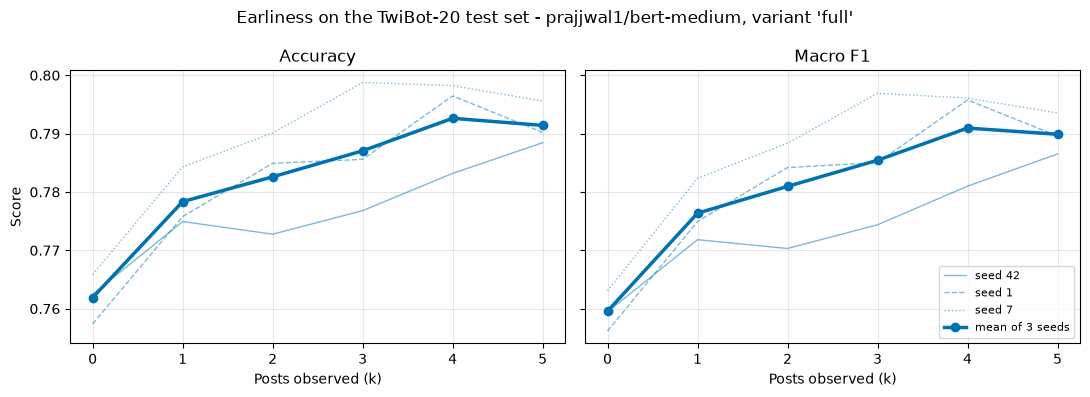


Macro-F1 gain from k=0 to k=5: +0.0270, +0.0334, +0.0305 (mean +0.0303)
Figure saved to out/earliness_prajjwal1-bert-medium_full.png and .pdf


In [16]:
report_experiment(runs_A1, color=PALETTE[0])


### A.2 - `roberta-base`, `full`

The reference encoder (124.6M parameters), and the best of the four on the
per-account metrics. Its seed 42 and seed 1 are the runs of the original
four-model comparison; seed 7 was added when every group moved to three seeds.


In [17]:
runs_A2 = run_experiment("roberta-base", "full")


roberta-base / full / seed 42: loaded out/results_roberta-base_full_seed42.json
roberta-base / full / seed 1: loaded out/results_roberta-base_full_seed1.json
roberta-base / full / seed 7: loaded out/results_roberta-base_full_seed7.json


roberta-base, variant 'full': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.7666    0.7878    0.7820   0.8177
     1        0.7731    0.7912    0.7887   0.8119
     7        0.7683    0.8005    0.7985   0.8187
  mean                  0.7932    0.7897   0.8161
    sd                  0.0066    0.0083   0.0037


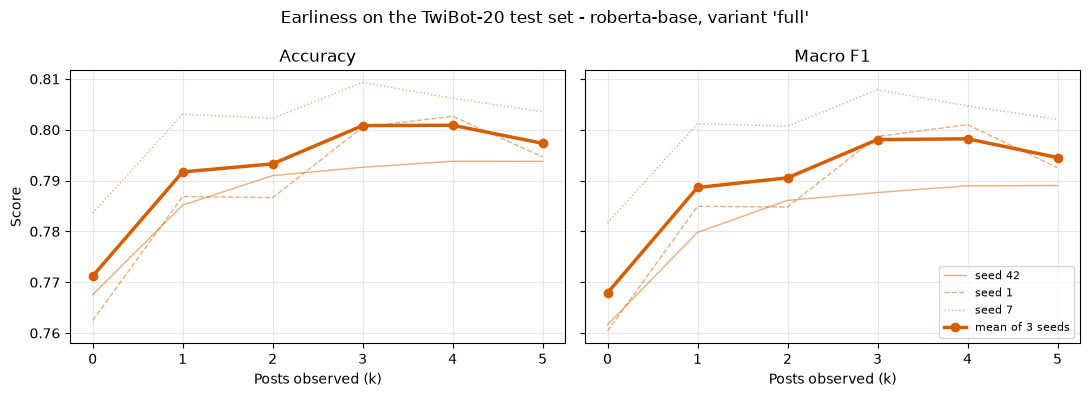


Macro-F1 gain from k=0 to k=5: +0.0274, +0.0321, +0.0204 (mean +0.0266)
Figure saved to out/earliness_roberta-base_full.png and .pdf


In [18]:
report_experiment(runs_A2, color=PALETTE[1])


### A.3 - `cardiffnlp/twitter-roberta-base-2021-124m`, `full`

The same architecture as A.2, further pre-trained on ~124M tweets: what to look
for is whether the in-domain vocabulary buys anything. The stories quote the
posts verbatim, but most of every story is template English, which is where
the two models start equal.


In [19]:
runs_A3 = run_experiment("cardiffnlp/twitter-roberta-base-2021-124m", "full")


cardiffnlp/twitter-roberta-base-2021-124m / full / seed 42: loaded out/results_cardiffnlp-twitter-roberta-base-2021-124m_full_seed42.json
cardiffnlp/twitter-roberta-base-2021-124m / full / seed 1: loaded out/results_cardiffnlp-twitter-roberta-base-2021-124m_full_seed1.json
cardiffnlp/twitter-roberta-base-2021-124m / full / seed 7: loaded out/results_cardiffnlp-twitter-roberta-base-2021-124m_full_seed7.json


cardiffnlp/twitter-roberta-base-2021-124m, variant 'full': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.7719    0.7777    0.7757   0.7969
     1        0.7700    0.7929    0.7894   0.8165
     7        0.7813    0.7954    0.7921   0.8183
  mean                  0.7887    0.7857   0.8106
    sd                  0.0096    0.0088   0.0119


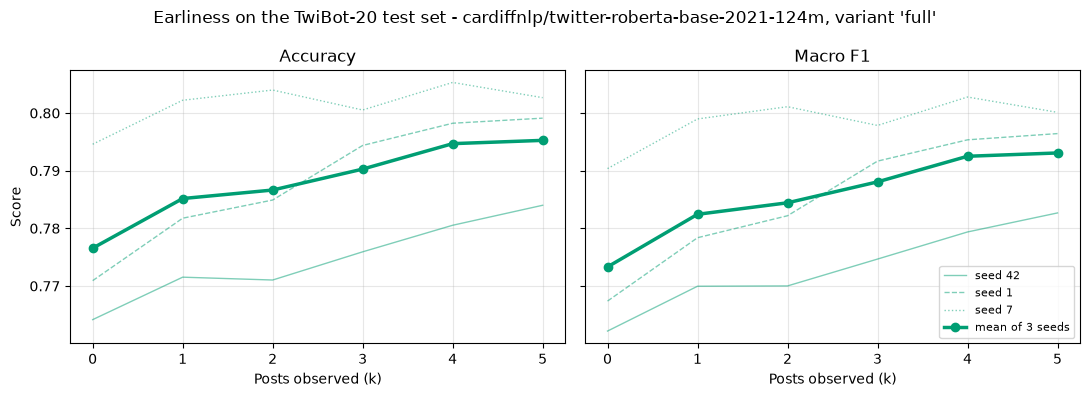


Macro-F1 gain from k=0 to k=5: +0.0205, +0.0291, +0.0098 (mean +0.0198)
Figure saved to out/earliness_cardiffnlp-twitter-roberta-base-2021-124m_full.png and .pdf


In [20]:
report_experiment(runs_A3, color=PALETTE[2])


### A.4 - `answerdotai/ModernBERT-base`, `full`

The most recent encoder (149.6M parameters). Its 8192-token window is unused at
`MAX_LENGTH = 512`, so it competes here without its one structural advantage,
and it is the slowest of the four on this GPU. What to look for is the spread
between its seeds, which is the widest of the group.


In [21]:
runs_A4 = run_experiment("answerdotai/ModernBERT-base", "full")


answerdotai/ModernBERT-base / full / seed 42: loaded out/results_answerdotai-ModernBERT-base_full_seed42.json
answerdotai/ModernBERT-base / full / seed 1: loaded out/results_answerdotai-ModernBERT-base_full_seed1.json
answerdotai/ModernBERT-base / full / seed 7: loaded out/results_answerdotai-ModernBERT-base_full_seed7.json


answerdotai/ModernBERT-base, variant 'full': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.7572    0.7591    0.7534   0.7909
     1        0.7629    0.7878    0.7830   0.8153
     7        0.7513    0.7904    0.7873   0.8127
  mean                  0.7791    0.7746   0.8063
    sd                  0.0174    0.0185   0.0134


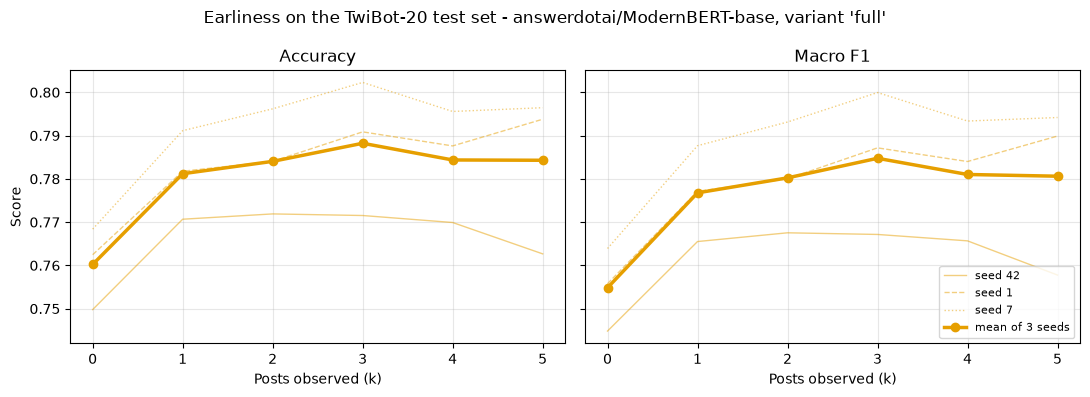


Macro-F1 gain from k=0 to k=5: +0.0129, +0.0341, +0.0303 (mean +0.0258)
Figure saved to out/earliness_answerdotai-ModernBERT-base_full.png and .pdf


In [22]:
report_experiment(runs_A4, color=PALETTE[3])


## 16. Group A comparison - which encoder

Two functions, defined here and reused by the other groups:

- `per_user_table` - one row per experiment with the per-account accuracy,
  macro-F1 and bot-F1 as **mean ± sd over the seeds**. A difference between two
  rows that is smaller than either row's sd is not a difference.
- `plot_earliness_comparison` - the earliness curves of every run of the group
  on one axis: accuracy on the left, macro-F1 on the right, colour and marker
  per configuration, line style per seed. The two panels share their axes, so
  the vertical gap between two curves is directly the gap between two runs.
  Saved as `out/earliness_comparison.png|pdf`.

For orientation, RoBERTa fine-tuned on raw tweets without a template scores
0.755 accuracy / 0.731 F1 in Feng et al. 2024; graph-based methods on TwiBot-20
are above 0.85, but they use the follow graph, which the stories do not.


experiment               seeds          accuracy          macro-F1            bot-F1
bert-medium (41.4M)          3   0.7847 ± 0.0027   0.7827 ± 0.0025   0.8033 ± 0.0059
roberta-base (124.6M)        3   0.7932 ± 0.0066   0.7897 ± 0.0083   0.8161 ± 0.0037
twitter-roberta (124.6M)     3   0.7887 ± 0.0096   0.7857 ± 0.0088   0.8106 ± 0.0119
ModernBERT-base (149.6M)     3   0.7791 ± 0.0174   0.7746 ± 0.0185   0.8063 ± 0.0134
sd = sample standard deviation over the seeds


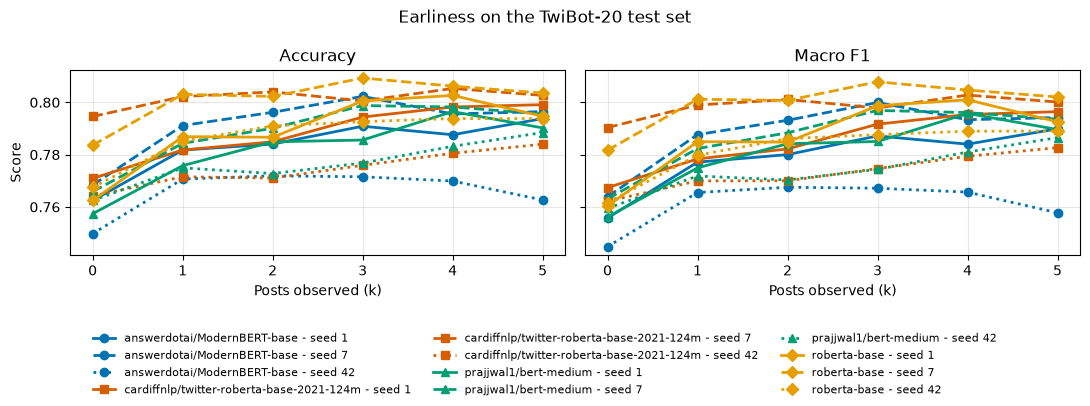

Figure saved to out/earliness_comparison.png and .pdf


In [23]:
def per_user_table(experiments):
    """Mean +- sd of the per-user metrics of several experiments, one row each."""
    width = max(len(label) for label in experiments)
    print(f"{'experiment':<{width}} {'seeds':>5} {'accuracy':>17} {'macro-F1':>17} {'bot-F1':>17}")
    for label, runs in experiments.items():
        cells = []
        for key in ("accuracy", "macro_f1", "binary_f1"):
            mean, sd = mean_sd([run["per_user"][key] for run in runs])
            cells.append(f"{mean:.4f} ± {sd:.4f}")
        print(f"{label:<{width}} {len(runs):5d} " + " ".join(f"{cell:>17}" for cell in cells))
    print("sd = sample standard deviation over the seeds")


def plot_earliness_comparison(runs, output_stem):
    """Draw the earliness curves of several runs side by side, and save the figure."""
    configuration = lambda run: (run["model"], run["variant"])
    configurations = sorted({configuration(run) for run in runs})
    seeds = sorted({run["seed"] for run in runs})
    if len(configurations) > len(PALETTE) or len(seeds) > len(LINESTYLES):
        raise ValueError(f"can draw up to {len(PALETTE)} configurations x "
                         f"{len(LINESTYLES)} seeds, got {len(configurations)} x {len(seeds)}")

    # The variant is named only when there is more than one to tell apart.
    show_variant = len({variant for _, variant in configurations}) > 1
    def describe(run):
        model, variant = configuration(run)
        return (f"{model} {variant}" if show_variant else model) + f" - seed {run['seed']}"

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for run in sorted(runs, key=lambda run: (configuration(run), run["seed"])):
        index = configurations.index(configuration(run))
        style = dict(color=PALETTE[index], marker=MARKERS[index],
                     linestyle=LINESTYLES[seeds.index(run["seed"])],
                     linewidth=2, markersize=6, label=describe(run))
        observed_posts = [k for k, _, _ in run["per_prefix"]]
        axes[0].plot(observed_posts, [accuracy for _, accuracy, _ in run["per_prefix"]], **style)
        axes[1].plot(observed_posts, [macro_f1 for _, _, macro_f1 in run["per_prefix"]], **style)

    for ax, metric in zip(axes, ("Accuracy", "Macro F1")):
        ax.set_title(metric)
        ax.set_xlabel("Posts observed (k)")
        ax.set_xticks(sorted({k for run in runs for k, _, _ in run["per_prefix"]}))
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Score")

    fig.suptitle("Earliness on the TwiBot-20 test set")
    legend_columns = min(len(runs), 3)
    legend_rows = -(-len(runs) // legend_columns)      # ceiling division
    fig.legend(*axes[0].get_legend_handles_labels(),
               loc="lower center", ncol=legend_columns, frameon=False, fontsize=8)
    fig.tight_layout(rect=(0, 0.04 + 0.045 * legend_rows, 1, 1))
    fig.savefig(f"{output_stem}.png", dpi=200)
    fig.savefig(f"{output_stem}.pdf")
    plt.show()
    print(f"Figure saved to {output_stem}.png and .pdf")


group_A = {"bert-medium (41.4M)": runs_A1, "roberta-base (124.6M)": runs_A2,
           "twitter-roberta (124.6M)": runs_A3, "ModernBERT-base (149.6M)": runs_A4}
per_user_table(group_A)
plot_earliness_comparison([run for runs in group_A.values() for run in runs],
                          os.path.join(FIGURE_DIR, "earliness_comparison"))


## 17. Group B - the ablation of the template on `bert-medium`

Group A measures what the posts add *on top of* the profile block. To measure
what they carry *on their own*, and whether summarising them helps, the
template is taken apart on one encoder - `bert-medium`, within seed noise of
`roberta-base` in §16 and the cheapest to run - with the same three seeds:

| Experiment | Profile block | Behaviour block | Posts |
|---|---|---|---|
| A.1 `full` | yes | no | `k` = 0..5 |
| B.1 `posts+stats` | no | yes | `k` = 1..8 |
| B.2 `full+stats` | yes | yes | `k` = 0..5 |

The three templates are illustrated on the same account in §7; the behaviour
block is the one described there, with the statistics the audit of §8
selected (`PROJECT.md` 6.6 has the full justification).

### B.1 - `prajjwal1/bert-medium`, `posts+stats`

No profile block: the story opens with the behaviour block and continues with
up to eight posts. Dropping the profile frees the ~150-200 tokens it occupies,
which is what lets `k` grow to 8 inside the same 512-token window (§9: 5.1% of
the stories overflow at `k = 8`, against 4.4% for the full template at
`k = 5`). An account with no post has no story at all, so this experiment
scores 1,173 test accounts rather than 1,183, and its earliness curve starts at
`k = 1`.


In [24]:
runs_B1 = run_experiment("prajjwal1/bert-medium", "posts+stats")


prajjwal1/bert-medium / posts+stats / seed 42: loaded out/results_prajjwal1-bert-medium_posts+stats_seed42.json
prajjwal1/bert-medium / posts+stats / seed 1: loaded out/results_prajjwal1-bert-medium_posts+stats_seed1.json
prajjwal1/bert-medium / posts+stats / seed 7: loaded out/results_prajjwal1-bert-medium_posts+stats_seed7.json


prajjwal1/bert-medium, variant 'posts+stats': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.6465    0.6701    0.6671   0.6984
     1        0.6599    0.6564    0.6547   0.6789
     7        0.6649    0.6820    0.6800   0.7056
  mean                  0.6695    0.6673   0.6943
    sd                  0.0128    0.0126   0.0138


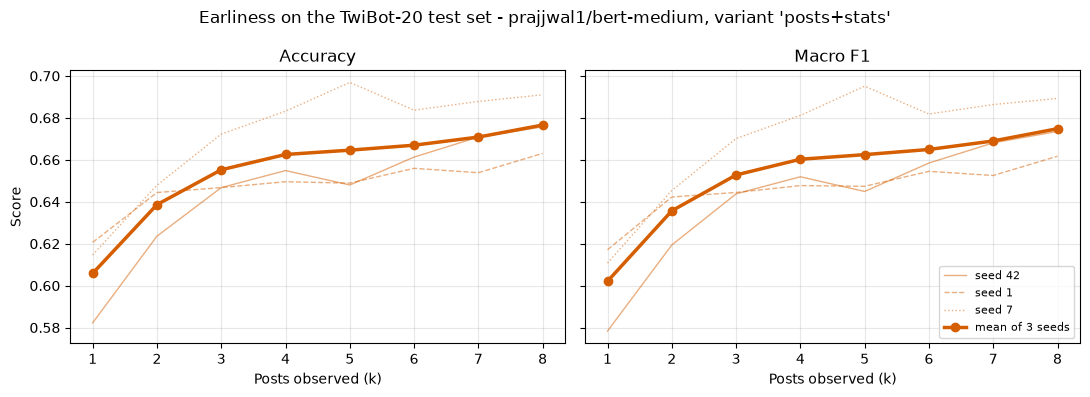


Macro-F1 gain from k=1 to k=8: +0.0952, +0.0446, +0.0785 (mean +0.0727)
Figure saved to out/earliness_prajjwal1-bert-medium_posts+stats.png and .pdf


In [25]:
report_experiment(runs_B1, color=PALETTE[1])


### B.2 - `prajjwal1/bert-medium`, `full+stats`

The full template with the behaviour block inserted between the profile and
the first post. Its `k = 0` stories are identical to A.1's, since the block
needs at least one post - which makes the `k = 0` row of the comparison a
built-in control: any gap there between B.2 and A.1 is training noise, not
input. Every other story is A.1's plus about 20 tokens.


In [26]:
runs_B2 = run_experiment("prajjwal1/bert-medium", "full+stats")


prajjwal1/bert-medium / full+stats / seed 42: loaded out/results_prajjwal1-bert-medium_full+stats_seed42.json
prajjwal1/bert-medium / full+stats / seed 1: loaded out/results_prajjwal1-bert-medium_full+stats_seed1.json
prajjwal1/bert-medium / full+stats / seed 7: loaded out/results_prajjwal1-bert-medium_full+stats_seed7.json


prajjwal1/bert-medium, variant 'full+stats': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.7577    0.7853    0.7851   0.7915
     1        0.7580    0.7785    0.7778   0.7904
     7        0.7581    0.7878    0.7862   0.8047
  mean                  0.7839    0.7831   0.7955
    sd                  0.0048    0.0046   0.0079


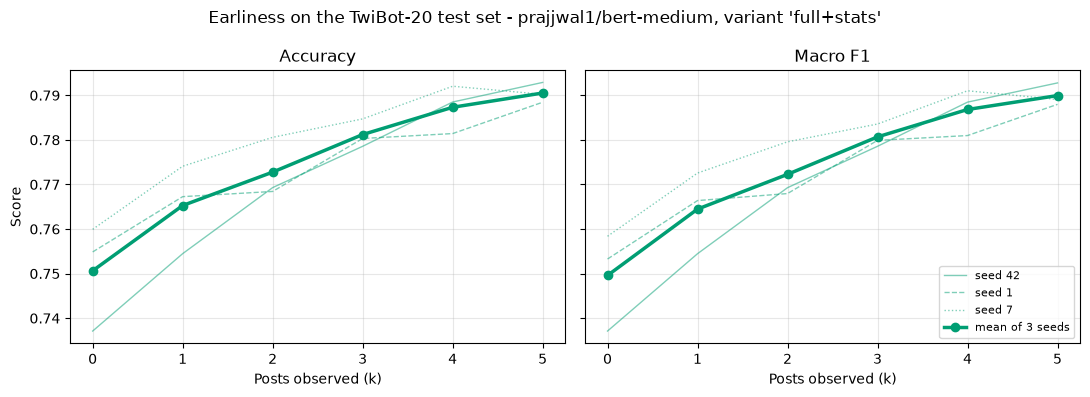


Macro-F1 gain from k=0 to k=5: +0.0557, +0.0347, +0.0307 (mean +0.0404)
Figure saved to out/earliness_prajjwal1-bert-medium_full+stats.png and .pdf


In [27]:
report_experiment(runs_B2, color=PALETTE[2])


## 18. Group B comparison - what the posts carry

Three views of the same nine runs:

1. **Per-account metrics** of the three templates, as in §16. The `posts+stats`
   row scores a slightly different population (the 10 accounts with no post are
   missing), which is one reason the third view exists.
2. **Earliness** of the three templates on one axis, `out/earliness_ablation`.
3. **Account by account.** Every run stores its prediction for every test
   account, so two templates can be compared on the accounts they share, seed
   by seed. `paired_comparison` prints, for each pair of experiments:
   - **McNemar's exact test** on the accounts that exactly one of the two gets
     right. The accounts both get right, or both get wrong, say nothing about
     the difference between the templates, so they are left out; what remains
     is a count of "only A right" against "only B right", and the test asks
     whether that split could be a coin toss. Two templates at the same
     macro-F1 can disagree on a fifth of the accounts - this is the comparison
     the averages cannot make;
   - the **operating point**: the share of accounts each template calls a bot,
     and its recall on each class. A template can leave the macro-F1 unchanged
     and still move the threshold - trade bot recall for human recall - which
     shows up here and nowhere else.


experiment        seeds          accuracy          macro-F1            bot-F1
full (A.1)            3   0.7847 ± 0.0027   0.7827 ± 0.0025   0.8033 ± 0.0059
posts+stats (B.1)     3   0.6695 ± 0.0128   0.6673 ± 0.0126   0.6943 ± 0.0138
full+stats (B.2)      3   0.7839 ± 0.0048   0.7831 ± 0.0046   0.7955 ± 0.0079
sd = sample standard deviation over the seeds


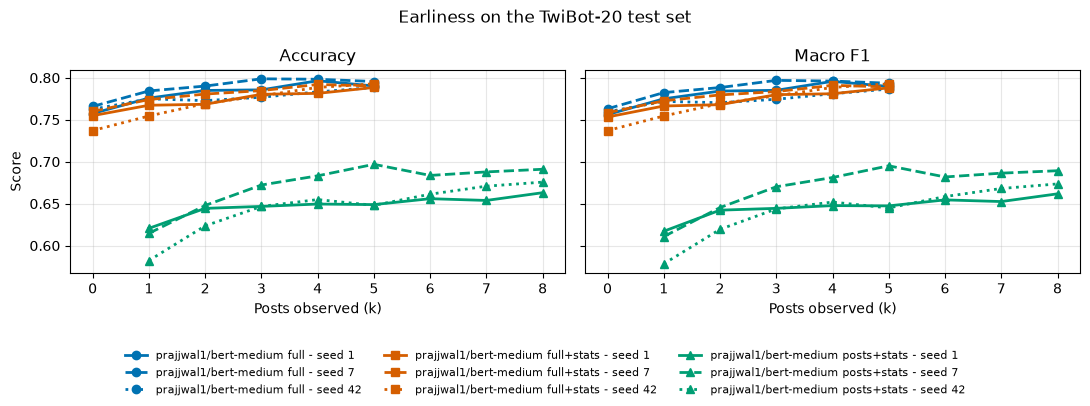

Figure saved to out/earliness_ablation.png and .pdf

full+stats against full, on the accounts both scored
  seed accounts  changed  only full+stats        only full       p
    42     1183      181               92               89   0.882
     1     1183      144               69               75   0.677
     7     1183      144               72               72   1.000
  pooled over the seeds: 233 against 236

  seed                 predicted bot  bot recall  human recall
    42     full+stats          0.489       0.753         0.823
    42           full          0.567       0.823         0.735
     1     full+stats          0.516       0.772         0.786
     1           full          0.526       0.786         0.781
     7     full+stats          0.545       0.808         0.764
     7           full          0.569       0.830         0.738

posts+stats against full, on the accounts both scored
  seed accounts  changed only posts+stats        only full       p
    42     1173      

In [28]:
from math import comb


def shared_predictions(run_a, run_b):
    """The (true, predicted_a, predicted_b) triples of the accounts both runs scored."""
    shared = sorted(set(run_a["per_user_predictions"]) & set(run_b["per_user_predictions"]))
    return [(run_a["per_user_predictions"][u][0], run_a["per_user_predictions"][u][1],
             run_b["per_user_predictions"][u][1]) for u in shared]


def mcnemar(triples):
    """Exact two-sided McNemar test: (only a right, only b right, p-value)."""
    only_a = sum(1 for true, a, b in triples if a == true and b != true)
    only_b = sum(1 for true, a, b in triples if a != true and b == true)
    n, k = only_a + only_b, min(only_a, only_b)
    p = min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0
    return only_a, only_b, p


def operating_point(pairs):
    """Predicted-bot share, bot recall and human recall from (true, predicted) pairs."""
    tp = sum(1 for t, p in pairs if t == 1 and p == 1)
    fn = sum(1 for t, p in pairs if t == 1 and p == 0)
    tn = sum(1 for t, p in pairs if t == 0 and p == 0)
    fp = sum(1 for t, p in pairs if t == 0 and p == 1)
    return (tp + fp) / len(pairs), tp / (tp + fn), tn / (tn + fp)


def paired_comparison(runs_a, runs_b, label_a, label_b):
    """McNemar and operating point of two experiments, seed by seed, on the shared accounts."""
    by_seed_b = {run["seed"]: run for run in runs_b}
    print(f"{label_a} against {label_b}, on the accounts both scored")
    print(f"  {'seed':>4} {'accounts':>8} {'changed':>8} {'only ' + label_a:>16} "
          f"{'only ' + label_b:>16} {'p':>7}")
    totals = [0, 0]
    for run_a in runs_a:
        triples = shared_predictions(run_a, by_seed_b[run_a["seed"]])
        only_a, only_b, p = mcnemar(triples)
        totals[0] += only_a; totals[1] += only_b
        changed = sum(1 for _, a, b in triples if a != b)
        print(f"  {run_a['seed']:4d} {len(triples):8d} {changed:8d} {only_a:16d} {only_b:16d} {p:7.3f}")
    print(f"  pooled over the seeds: {totals[0]} against {totals[1]}")
    print(f"\n  {'seed':>4} {'':>14} {'predicted bot':>14} {'bot recall':>11} {'human recall':>13}")
    for run_a in runs_a:
        triples = shared_predictions(run_a, by_seed_b[run_a["seed"]])
        for label, pairs in ((label_a, [(true, a) for true, a, _ in triples]),
                             (label_b, [(true, b) for true, _, b in triples])):
            share, bot_recall, human_recall = operating_point(pairs)
            print(f"  {run_a['seed']:4d} {label:>14} {share:14.3f} {bot_recall:11.3f} {human_recall:13.3f}")
    print()


group_B = {"full (A.1)": runs_A1, "posts+stats (B.1)": runs_B1, "full+stats (B.2)": runs_B2}
per_user_table(group_B)
plot_earliness_comparison([run for runs in group_B.values() for run in runs],
                          os.path.join(FIGURE_DIR, "earliness_ablation"))
print()
paired_comparison(runs_B2, runs_A1, "full+stats", "full")
paired_comparison(runs_B1, runs_A1, "posts+stats", "full")
paired_comparison(runs_B1, runs_B2, "posts+stats", "full+stats")


## 19. Group C - the `verified` artifact

On the training split `verified` is true for 56.6% of the humans and for none
of the 4,646 bots (§5): the annotators most likely used the blue check as a
heuristic for labelling humans, and the trivial rule "verified → human" alone
classifies 2,057 of the 8,278 training accounts correctly. Every other
experiment leaves the field out of the profile block for that reason. This one
puts it back, on the full template and `bert-medium`, to measure how much of
the performance the artifact would buy - the third research question of the
project.

### C.1 - `prajjwal1/bert-medium`, `full+verified`

Identical to A.1 except for one clause of the profile sentence: *It is
verified, uses the default profile layout, …* instead of *It is uses the
default profile layout, …* (the example account of §7 gets *It is not
verified, …*). That also fixes the grammar of the sentence, so the comparison
mixes the field with that wording change; the field is by far the larger
difference.


In [29]:
runs_C1 = run_experiment("prajjwal1/bert-medium", "full+verified")


prajjwal1/bert-medium / full+verified / seed 42: loaded out/results_prajjwal1-bert-medium_full+verified_seed42.json
prajjwal1/bert-medium / full+verified / seed 1: loaded out/results_prajjwal1-bert-medium_full+verified_seed1.json
prajjwal1/bert-medium / full+verified / seed 7: loaded out/results_prajjwal1-bert-medium_full+verified_seed7.json


prajjwal1/bert-medium, variant 'full+verified': one prediction per account at its longest prefix

  seed  dev macro-F1  accuracy  macro-F1   bot-F1
    42        0.8065    0.8183    0.8163   0.8352
     1        0.8147    0.8335    0.8290   0.8567
     7        0.8114    0.8326    0.8291   0.8536
  mean                  0.8281    0.8248   0.8485
    sd                  0.0086    0.0074   0.0116


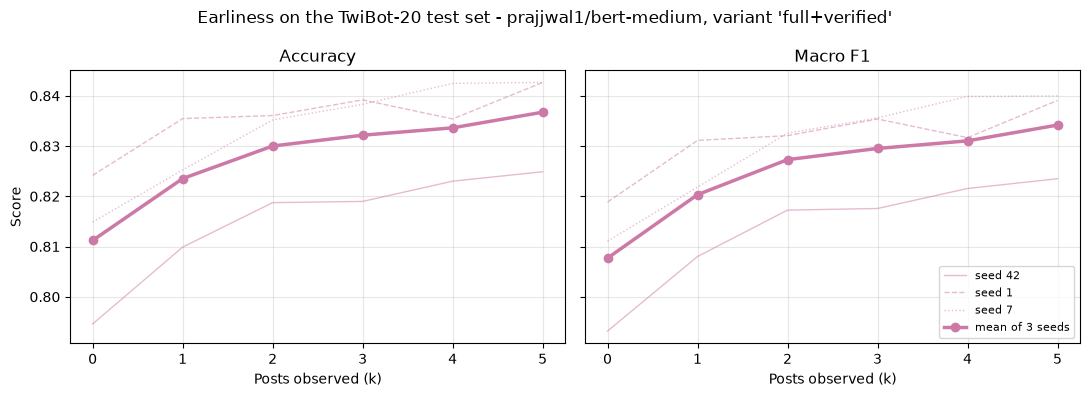


Macro-F1 gain from k=0 to k=5: +0.0303, +0.0202, +0.0289 (mean +0.0265)
Figure saved to out/earliness_prajjwal1-bert-medium_full+verified.png and .pdf


In [30]:
report_experiment(runs_C1, color=PALETTE[4])


## 20. Group C comparison - how much the artifact is worth

`full+verified` against `full` (A.1): the same accounts, seeds and encoder, one
field of difference. The per-account gap is the share of the performance that
comes from the annotation artifact rather than from genuine signal; the
earliness curves show where it enters - at `k = 0` the profile is all the
model sees - and the paired comparison shows how: which class the extra
accuracy is bought on, and whether every seed agrees. For scale, the rule
"verified → human, otherwise bot", with no model at all, scores 0.8166
accuracy on the test split.


experiment          seeds          accuracy          macro-F1            bot-F1
full (A.1)              3   0.7847 ± 0.0027   0.7827 ± 0.0025   0.8033 ± 0.0059
full+verified (C.1)     3   0.8281 ± 0.0086   0.8248 ± 0.0074   0.8485 ± 0.0116
sd = sample standard deviation over the seeds


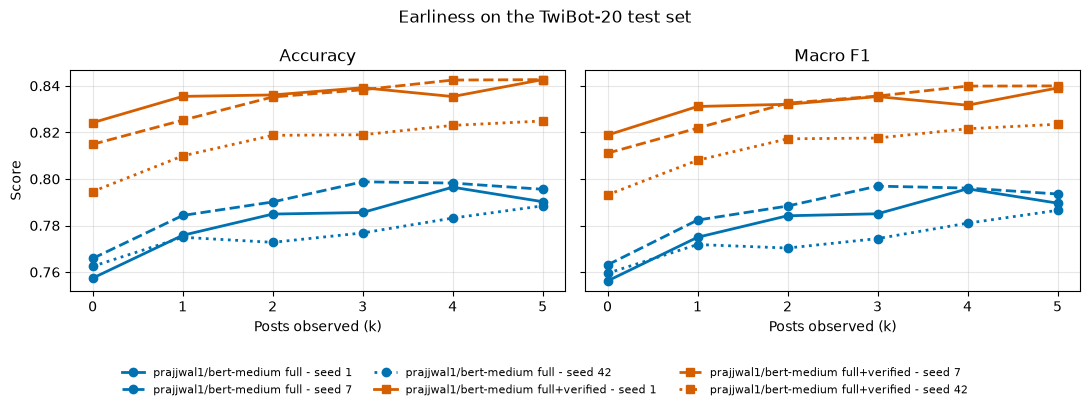

Figure saved to out/earliness_verified.png and .pdf

full+verified against full, on the accounts both scored
  seed accounts  changed only full+verified        only full       p
    42     1183      180              111               69   0.002
     1     1183      201              130               71   0.000
     7     1183      177              115               62   0.000
  pooled over the seeds: 356 against 202

  seed                 predicted bot  bot recall  human recall
    42  full+verified          0.562       0.852         0.779
    42           full          0.567       0.823         0.735
     1  full+verified          0.621       0.920         0.731
     1           full          0.526       0.786         0.781
     7  full+verified          0.602       0.902         0.751
     7           full          0.569       0.830         0.738



In [31]:
group_C = {"full (A.1)": runs_A1, "full+verified (C.1)": runs_C1}
per_user_table(group_C)
plot_earliness_comparison([run for runs in group_C.values() for run in runs],
                          os.path.join(FIGURE_DIR, "earliness_verified"))
print()
paired_comparison(runs_C1, runs_A1, "full+verified", "full")
